
</p>
<img src="scs system image.png" alt="Otter logo" width="280" align="left" style="margin-right: 15px; border-radius: 8px;">

# Otter Hydraulic System — Condition Monitoring Notebook #2 (Data Exploration)

This is clean final version of notebook which runs a data processing pipeline to wrangle the data for last 4 years, create feature parameters then explore the data to understand the hydraulic system opearation.
The functions pipeline is located at /piplines/otter_pipeline_function_defiinitons.py

**Tasks**
- Extract and process data from **2017–2024**  
- Clean and align time-series signals across multiple sources  
- Add derived features (e.g., rates of change, smoothed tank levels, fluid consumption)  
- Perform  data exploration and validation checks  
- Visualise trends and distributions to assess data 


In [44]:
# Import all Libraries for this notebook
import pandas as pd
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import shap
from IPython.display import HTML, display
import matplotlib.dates as mdates
from scipy.stats import pearsonr, spearmanr
from scipy.fft import fft, fftfreq
from sklearn.linear_model import LinearRegression
import sys
import os
import gc
import seaborn as sns


In [45]:
# Load my pipline functions from the pipeline definitions file

pipeline_path = os.path.abspath('../pipeline')
if pipeline_path not in sys.path:
    sys.path.append(pipeline_path)

# Now import your modules
import otter_config as cfg # contains all filepaths and global variables/parameters

#All functions located here
from otter_pipeline_function_definitions import (
    load_and_clean_otter_data,
    process_valve_data,
    valve_fluid_usage_calc,
    process_fcv,
    process_pcv,
    convert_tank_levels,
    process_umbilical_charges,
    system_fluid_consumption,
    system_fluid_consumption_v2,
    add_smoothed_supply_level_litres,
    add_external_losses,
    add_external_loss_moving_averages,
    add_daily_ewm_to_minutely_df,
    add_baseline_columns,
    add_pressure_deltas,
    add_pump_run_cumulatives,
    add_slope_features,
    add_smoothed_return_level_litres,
    clean_dataframe_and_split_valves,
    run_full_pipeline,
    compute_baseline_drift,
    summarise_dataframe,
    calculate_drop_slopes_fast
    #calculate_pressure_slopes_fast
)

In [46]:
#DEfine where data File Paths (from notebook 1) is located
parquet_path = r"C:\Users\rosst\OneDrive\Control Integrity\Data\Otter 2003 to 2024 with tanks B\Parquet_Clean_Output\Otter_All_Combined_PCV_180825.parquet" 



#### Run the data processing pipline 
Run on the last 7 years of data out of the 20 avialable years (2017 to 2024). The pipeline will clean and process data adding all relevant feature data points to the timeseries DF

In [47]:
df_all_otter = run_full_pipeline(
    parquet_path=r"C:\Users\rosst\OneDrive\Control Integrity\Data\Otter 2003 to 2024 with tanks B\Parquet_Clean_Output\Otter_All_Combined_PCV_180825.parquet" ,
    columns_to_remove=cfg.columns_to_remove,
    valve_columns=cfg.valve_columns,
    valve5_volume=cfg.valve5_volume,
    valve2_volume=cfg.valve2_volume,
    valve_hp_volume=cfg.valve_hp_volume,
    pcv_columns=cfg.pcv_columns,
    thresholds=cfg.thresholds,
    
    pump_events_path=cfg.pump_events_path,
    valve_transition_cols=cfg.valve_transition_cols,
    drop_slope_data_path=cfg.drop_slope_data_path,
    use_smoothed_tank=True,          #
    smoothing_strength=5,          
    combine_sensors="both",
    years_back=7
)

Loaded 3682088 rows × 69 cols (last 7 years: 2017-05-01 → 2024-05-01)
✅ Transition tracking columns created and combined metrics computed.
✅ FCV processing complete: full steps & fluid usage added.
✅ PCV processing complete: steps & fluid usage added.
✅ Tank levels converted to litres for: HPU_SPLY_LEV_L, HPU_SPLY_LEV_B_L, HPU_RET_LEV_L, HPU-RET_LEV_B_L
Dropped 427 duplicate rows from slope_df.


In [ ]:
#check the data frame columns
vol_cols = df_all_otter.columns.tolist()
print(vol_cols)

['HPU_SPLY_LEV', 'HPU_RET_LEV', 'HPU_LP_A_SPLY', 'HPU_LP_B_SPLY', 'HPU_HP_A_SPLY', 'HPU_HP_B_SPLY', 'HPU_LPA_OUT', 'HPU_LPB_OUT', 'HPU_HPA_OUT', 'HPU_HPB_OUT', 'SCM1_LP_CONS', 'SCM1_HP_CONS', 'SCM1_RET', 'SCM2_LP_CONS', 'SCM2_RET', 'P3_PMV', 'P3_PWV', 'P3_AMV', 'P3_SCSSV', 'P3_PDV', 'P3_TDV', 'P1_PMV', 'P1_PWV', 'P1_AMV', 'P1_SCSSV', 'P1_PDV', 'P1_TDV', 'P2_PMV', 'P2_PWV', 'P2_AMV', 'P2_SCSSV', 'P2_PDV', 'P2_TDV', 'I1_PMV', 'I1_PWV', 'I1_AMV', 'I2_PMV', 'I2_PWV', 'I2_AMV', 'FCV_CPI', 'P1_PCV', 'P2_PCV', 'P3_PCV', 'I1_PCV', 'I2_PCV', 'MPMV_Inlet', 'Man_CI', 'SCM1_LP1_COV', 'SCM1_HP_COV', 'HPU_SPLY_LEV_B', 'HPU-RET_LEV_B', 'SCM2_LP1_COV', 'SCM2_HP_COV', 'SCM3_LP1_COV', 'SCM3_HP_COV', 'SCM4_LP1_COV', 'SCM4_HP_COV', 'SCM5_LP1_COV', 'SCM5_HP_COV', 'SCM3_LP_CONS', 'SCM3_HP_CONS', 'SCM3_RET', 'SCM4_LP_CONS', 'SCM4_HP_CONS', 'SCM4_RET', 'SCM5_LP_CONS', 'SCM5_HP_CONS', 'SCM5_RET', 'P1_PMV_OpenToClosed', 'P1_PMV_ClosedToOpen', 'P1_PWV_OpenToClosed', 'P1_PWV_ClosedToOpen', 'P1_AMV_OpenToClosed', 

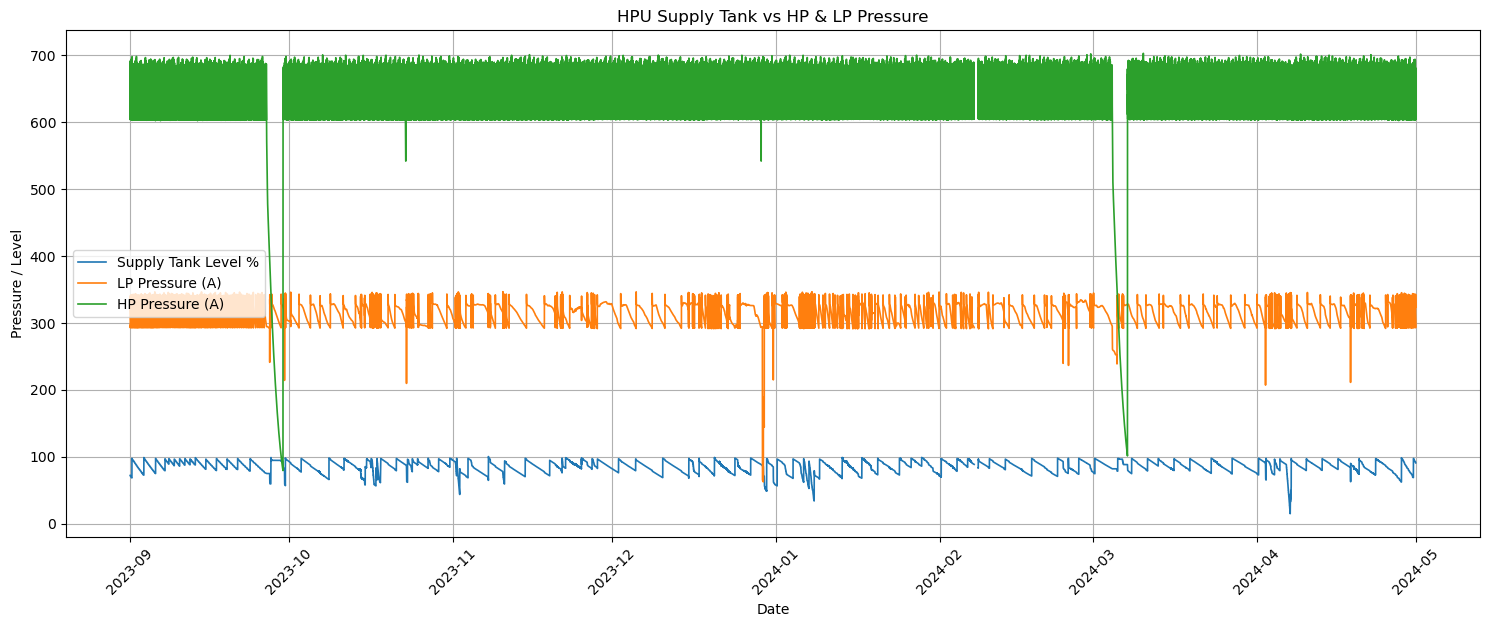

In [ ]:
# Quick check of dataframe to ensure all is correct (from notebook1)

#Plot relevant data points 
supply_col = 'HPU_SPLY_LEV'
lp_pressure_col = 'HPU_LP_A_SPLY'
hp_pressure_col = 'HPU_HP_A_SPLY'

# Filter 2 yhears
start_date = '2023-09-01'
end_date = '2024-04-30'
df_plot = df_all_otter.loc[start_date:end_date, [supply_col, lp_pressure_col, hp_pressure_col]]

# Plot
plt.figure(figsize=(15, 6))
plt.plot(df_plot.index, df_plot[supply_col], label='Supply Tank Level %', linewidth=1.2)
plt.plot(df_plot.index, df_plot[lp_pressure_col], label='LP Pressure (A)', linewidth=1.2)
plt.plot(df_plot.index, df_plot[hp_pressure_col], label='HP Pressure (A)', linewidth=1.2)

plt.title('HPU Supply Tank vs HP & LP Pressure')
plt.xlabel('Date')
plt.ylabel('Pressure / Level')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)  # rotate for better readability
plt.show()

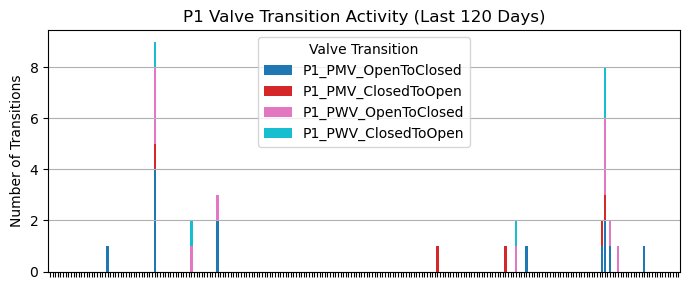

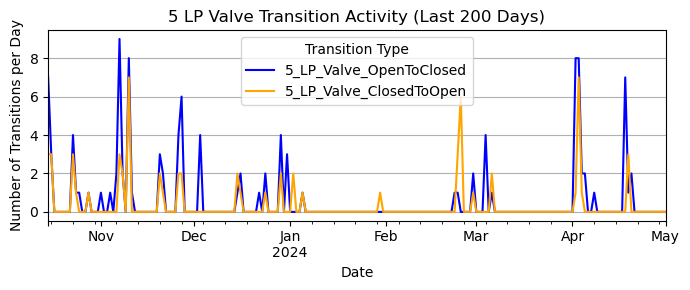

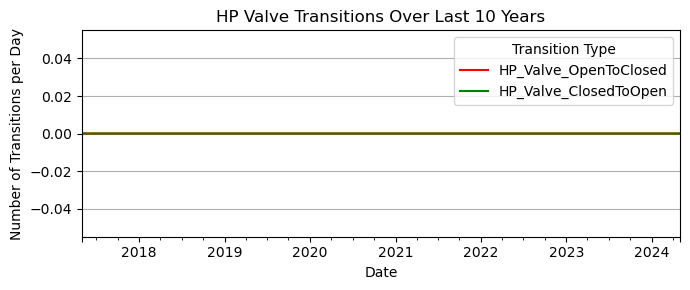

In [ ]:
#Plot and explore Valve Data
df_plot = df_all_otter[['P1_PMV_OpenToClosed', 'P1_PMV_ClosedToOpen',
                        'P1_PWV_OpenToClosed', 'P1_PWV_ClosedToOpen']].last('240D')

# Resample to daily counts
daily_counts = df_plot.resample('D').sum()

# Plot
fig, ax = plt.subplots(figsize=(7, 3))
daily_counts.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', width=0.9)

# Clean up formatting
plt.title("P1 Valve Transition Activity (Last 120 Days)")
plt.ylabel("Number of Transitions")
ax.set_xlabel("")  # Remove x-axis label
ax.tick_params(axis='x', labelbottom=False)  # Remove x-axis tick labels
plt.grid(True, axis='y')
plt.tight_layout()
plt.legend(title="Valve Transition")
plt.show()

# Resample daily totals
lp5_valve_trend = df_all_otter[['5_LP_Valve_OpenToClosed', '5_LP_Valve_ClosedToOpen']].resample('D').sum().last('200D')

# Plotting
fig, ax = plt.subplots(figsize=(7, 3))
lp5_valve_trend.plot(ax=ax, color=['blue', 'orange'])

plt.title("5 LP Valve Transition Activity (Last 200 Days)")
plt.ylabel("Number of Transitions per Day")
plt.xlabel("Date")
plt.grid(True, axis='y')
plt.legend(title="Transition Type")
plt.tight_layout()
plt.show()

hp_valve_trend = df_all_otter[['HP_Valve_OpenToClosed', 'HP_Valve_ClosedToOpen']].resample('D').sum().last('3650D')

# Plot
fig, ax = plt.subplots(figsize=(7, 3))
hp_valve_trend.plot(ax=ax, color=['red', 'green'])

plt.title("HP Valve Transitions Over Last 10 Years")
plt.ylabel("Number of Transitions per Day")
plt.xlabel("Date")
plt.grid(True, axis='y')
plt.legend(title="Transition Type")
plt.tight_layout()
plt.show()

del df_plot

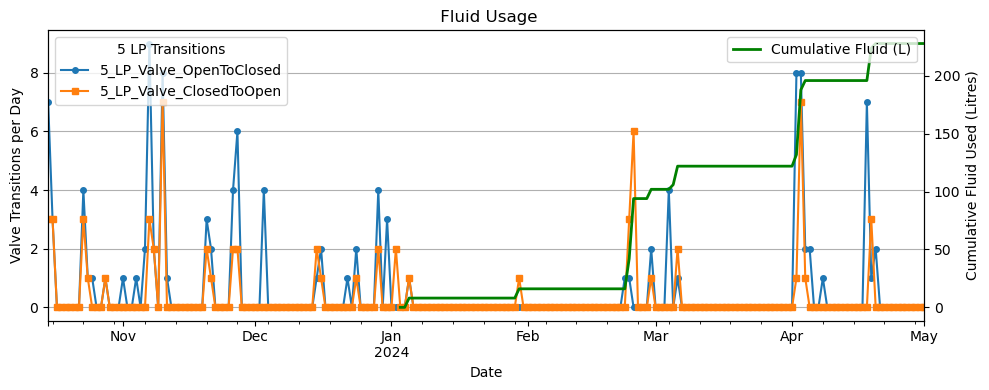

In [ ]:
# --- Plot and explore Valve Fluid Usage
valve_counts = (
    df_all_otter[['5_LP_Valve_OpenToClosed', '5_LP_Valve_ClosedToOpen']]
    .resample('D')
    .sum()
    .last('200D')
)

daily_fluid = (
    df_all_otter['Valve_Operation_Fluid']
    .resample('D')
    .sum()
    .last('120D')
)
cum_fluid = daily_fluid.cumsum()

fig, ax1 = plt.subplots(figsize=(10, 4))


valve_counts.plot(ax=ax1, style=['-o', '-s'], markersize=4)
ax1.set_ylabel("Valve Transitions per Day")
ax1.set_xlabel("Date")
ax1.grid(axis='y')
ax1.legend(title="5 LP Transitions", loc='upper left')


ax2 = ax1.twinx()
ax2.plot(cum_fluid.index, cum_fluid.values, color='green', linewidth=2, label='Cumulative Fluid (L)')
ax2.set_ylabel("Cumulative Fluid Used (Litres)")
ax2.legend(loc='upper right')

plt.title(" Fluid Usage")
plt.tight_layout()
plt.show()

del daily_fluid

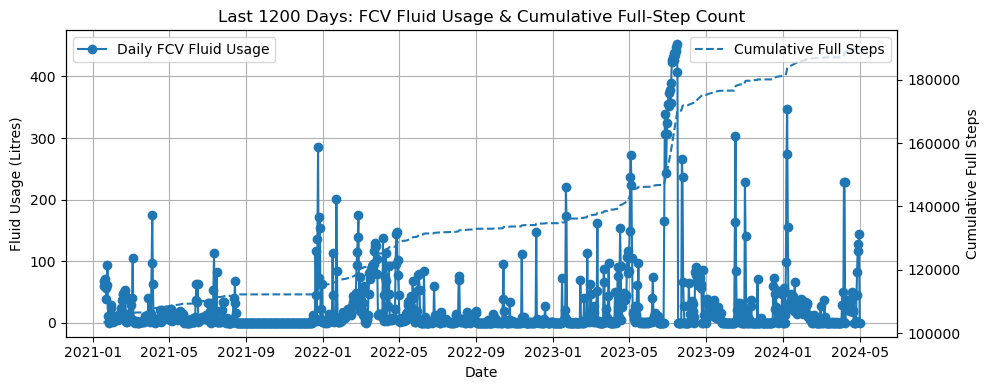

In [ ]:
# Plot and Explore the Flow Control Choke Valve operation and fluid consumption
daily_fcv_fluid = (
    df_all_otter['FCV_Fluid_Usage']
    .resample('D')
    .sum()
    .last('1200D')
)

# 3) Daily cumulative full‐step count (last 1200 days)
daily_cum_steps = (
    df_all_otter['FCV_CPI_FullSteps']
    .resample('D')
    .max()
    .last('1200D')
)

# 4) Plot
fig, ax1 = plt.subplots(figsize=(10, 4))

# Fluid usage
ax1.plot(daily_fcv_fluid.index, daily_fcv_fluid.values, marker='o', label='Daily FCV Fluid Usage')
ax1.set_xlabel("Date")
ax1.set_ylabel("Fluid Usage (Litres)")
ax1.grid(True)
ax1.legend(loc='upper left')

# Cumulative full steps on secondary axis
ax2 = ax1.twinx()
ax2.plot(daily_cum_steps.index, daily_cum_steps.values, linestyle='--', label='Cumulative Full Steps')
ax2.set_ylabel("Cumulative Full Steps")
ax2.legend(loc='upper right')

plt.title("Last 1200 Days: FCV Fluid Usage & Cumulative Full-Step Count")
plt.tight_layout()
plt.show()

del daily_fcv_fluid


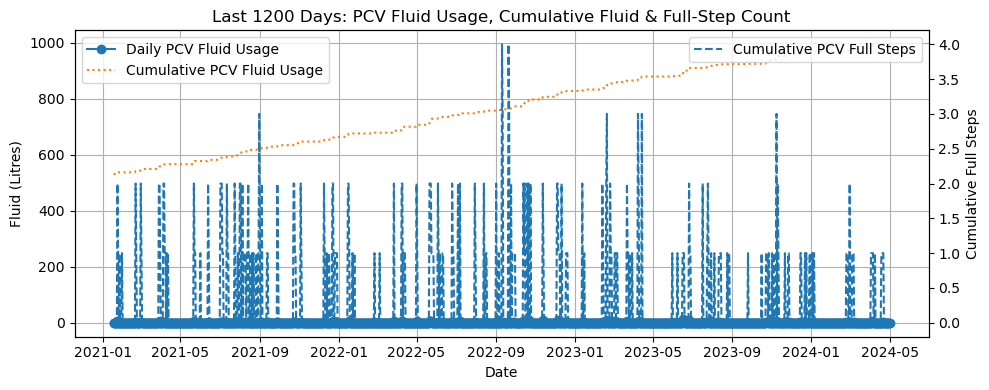

In [ ]:
# Plot and explore the Production Choke Valve operation and usage (doesnta actually use much fluid)

daily_pcv_fluid = (
    df_all_otter['PCV_Fluid_Usage']
    .resample('D')
    .sum()
    .last('1200D')
)

daily_cum_pcv_steps = (
    df_all_otter['PCV_FullSteps']
    .resample('D')
    .max()
    .last('1200D')
)

daily_cum_pcv_fluid = (
    df_all_otter['Cumulative_PCV_Fluid_Usage']
    .resample('D')
    .max()
    .last('1200D')
)

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(
    daily_pcv_fluid.index,
    daily_pcv_fluid.values,
    marker='o',
    label='Daily PCV Fluid Usage')

ax1.plot(
    daily_cum_pcv_fluid.index,
    daily_cum_pcv_fluid.values,
    linestyle=':',
    label='Cumulative PCV Fluid Usage'
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Fluid (Litres)")
ax1.grid(True)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(
    daily_cum_pcv_steps.index,
    daily_cum_pcv_steps.values,
    linestyle='--',
    label='Cumulative PCV Full Steps'
)
ax2.set_ylabel("Cumulative Full Steps")
ax2.legend(loc='upper right')

plt.title("Last 1200 Days: PCV Fluid Usage, Cumulative Fluid & Full-Step Count")
plt.tight_layout()
plt.show()

del daily_pcv_fluid
del daily_cum_pcv_fluid
del daily_cum_pcv_steps


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


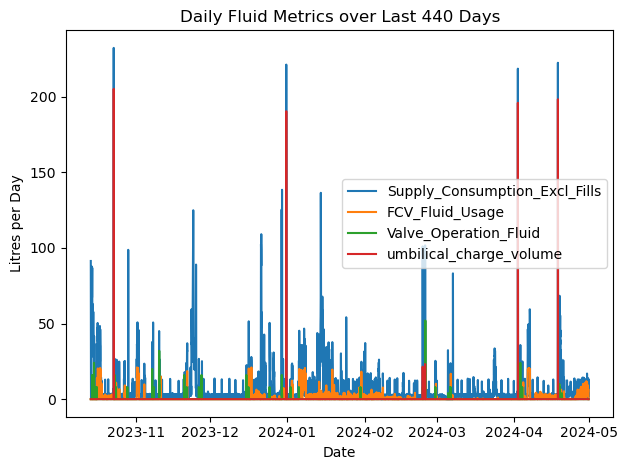

In [ ]:
# Plot of calculated fluiod usage to determine external losses i.e. Total fluid Use - Operational Usage/Accounted for Usage 
# Operatianal usage is the valves, chokes, umbilical charge usage volumes

# Restrict to the most recent 120 days
df_recent = df_all_otter.last('200D')
df_recent=system_fluid_consumption(df_recent)

# 1. Daily sums for each metric #Supply_Consumption_Excl_Fills
daily = df_recent[['Supply_Consumption_Excl_Fills',
                   'FCV_Fluid_Usage',
                   'Valve_Operation_Fluid','umbilical_charge_volume'
                   ]].resample('H').sum()

# 2. Daily cumulative values (take last value of each day)
cum = df_recent[[ 'Cumulative_FCV_Fluid_Usage',
                 'Cumulative_Valve_Operation_Fluid','umbilical_charge_volume'
                ]].resample('H').last()

# Plot A: Daily metrics
plt.figure()
for col in daily.columns:
    plt.plot(daily.index, daily[col], label=col)
plt.title("Daily Fluid Metrics over Last 440 Days")
plt.xlabel("Date")
plt.ylabel("Litres per Day")
plt.legend()
plt.tight_layout()
plt.show()

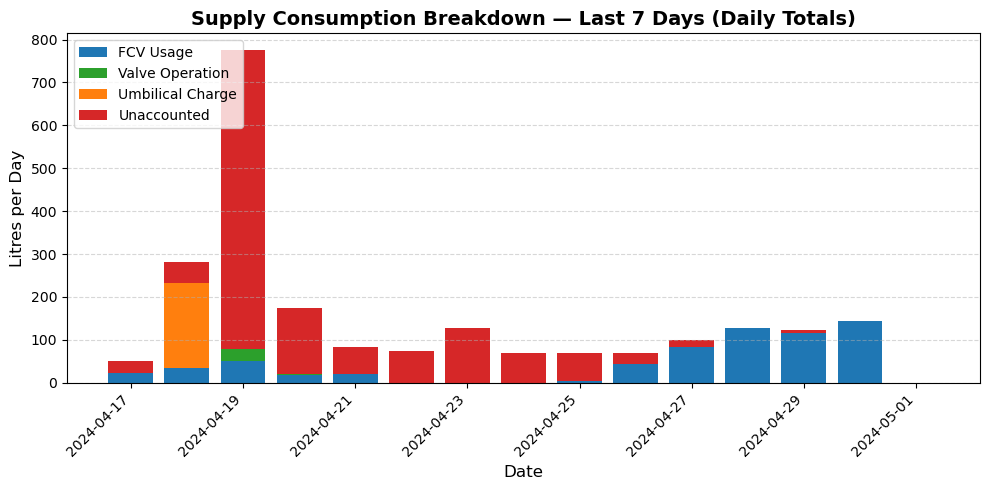

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- pick the last 7 days
df7 = df_all_otter.last("14D").copy()

# --- daily totals
supply = df7["Supply_Consumption_Excl_Fills"].resample("D").sum().fillna(0)
fcv    = df7["FCV_Fluid_Usage"].resample("D").sum().fillna(0)
valves = df7["Valve_Operation_Fluid"].resample("D").sum().fillna(0)
umb    = df7["umbilical_charge_volume"].resample("D").sum().fillna(0)

# --- remainder (unaccounted-for). Never let it go negative.
unaccounted = (supply - (fcv + valves + umb)).clip(lower=0)

# --- build DataFrame for plotting
plot_df = pd.DataFrame({
    "FCV Usage": fcv,
    "Valve Operation": valves,
    "Umbilical Charge": umb,
    "Unaccounted": unaccounted
}, index=supply.index)

# --- colors (professional palette)
colors = {
    "FCV Usage": "#1f77b4",       # blue
    "Valve Operation": "#2ca02c", # green
    "Umbilical Charge": "#ff7f0e",# orange
    "Unaccounted": "#d62728"      # red
}

# --- stacked bar plot
fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(plot_df))

for col in plot_df.columns:
    ax.bar(plot_df.index, plot_df[col].values, bottom=bottom,
           label=col, color=colors[col])
    bottom += plot_df[col].values

# --- styling
ax.set_title("Supply Consumption Breakdown — Last 7 Days (Daily Totals)", fontsize=14, weight="bold")
ax.set_ylabel("Litres per Day", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.legend(loc="upper left", frameon=True, fontsize=10)
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


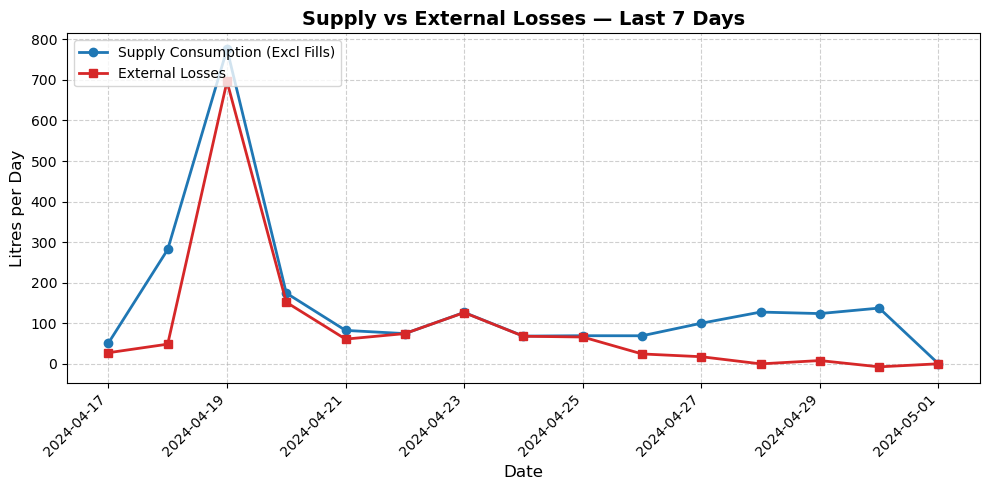

In [ ]:
import matplotlib.pyplot as plt

# --- restrict to last 7 days
df7 = df_all_otter.last("14D").copy()

# --- resample to daily totals
supply = df7["Supply_Consumption_Excl_Fills"].resample("D").sum().fillna(0)
losses = df7["External_Losses"].resample("D").sum().fillna(0)

# --- line plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(supply.index, supply.values, label="Supply Consumption (Excl Fills)",
        color="#1f77b4", linewidth=2, marker="o")
ax.plot(losses.index, losses.values, label="External Losses",
        color="#d62728", linewidth=2, marker="s")

# --- styling
ax.set_title("Supply vs External Losses — Last 7 Days", fontsize=14, weight="bold")
ax.set_ylabel("Litres per Day", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.legend(loc="upper left", frameon=True, fontsize=10)
ax.grid(True, linestyle="--", alpha=0.6)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


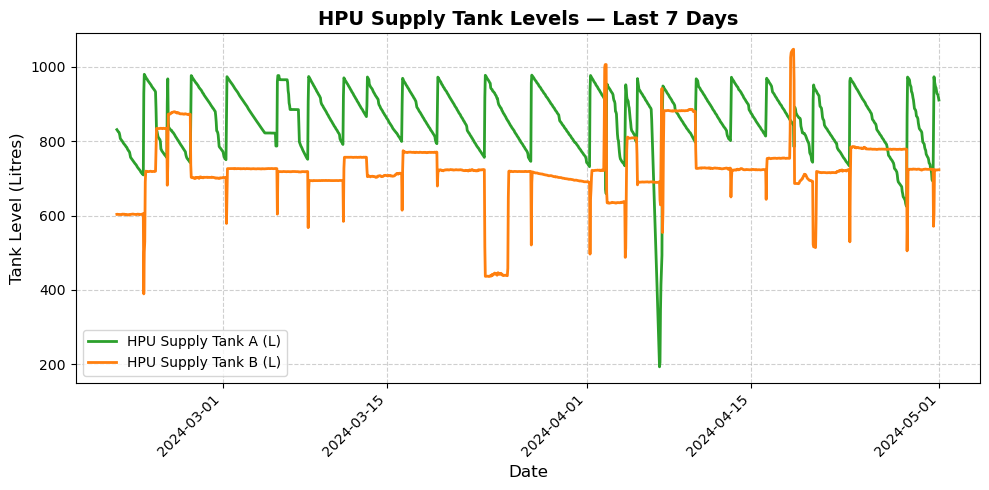

In [ ]:
# Explore Supply and Return Tank Level transmitters

# --- restrict to last 7 days
df7 = df_all_otter.last("70D").copy()

# --- resample to daily means (levels are continuous, not totals)
lev_a = df7["HPU_SPLY_LEV_L"].resample("H").mean().fillna(method="ffill")
lev_b = df7["HPU_RET_LEV_L"].resample("H").mean().fillna(method="ffill")

# --- line plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(lev_a.index, lev_a.values, label="HPU Supply Tank A (L)",
        color="#2ca02c", linewidth=2)
ax.plot(lev_b.index, lev_b.values, label="HPU Supply Tank B (L)",
        color="#ff7f0e", linewidth=2)

# --- styling
ax.set_title("HPU Supply Tank Levels — Last 7 Days", fontsize=14, weight="bold")
ax.set_ylabel("Tank Level (Litres)", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.legend(loc="best", frameon=True, fontsize=10)
ax.grid(True, linestyle="--", alpha=0.6)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Detect Tank Fill Events

When the tank level increases, it indicates a manual top-up.  
This routine detects and records those refill events automatically.

**Process Overview**

1. Take the tank-level time series.  
2. Compute minute-to-minute increases — ignore small fluctuations and cap unrealistic jumps.  
3. Group consecutive increases into a single fill event.  
   - If there’s a gap > 3 minutes, the event is closed.  
4. Sum the total litres in each event and discard small fills (< 10 L).  

**Outputs**

| Column | Description |
|:--|:--|
| `fill_event_id` | Identifier for each detected fill event |
| `tank_fill_volume` | Total volume (L) per event, stamped at the event’s end time |
| `tank_fill_cum` | Running cumulative total of all detected fills (L) |


In [ ]:
# Detect the tank fill events i.e. when the tank level increases it is being manually topped up. This volume needs to be recorded.

def detect_fills_safe(
    df: pd.DataFrame,
    level_col: str = "HPU_SPLY_LEV_L",
    min_event_litres: float = 10.0,     # ignore <10 L
    step_noise: float = 0.5,            # ignore tiny wiggles per min
    max_gap: str = "3min",              # bridge short pauses inside a fill
    max_step_litres: float = 150.0,     # sanity cap per minute rise
    smooth_window: str = "5min"  # light median smoothing; None to disable
) -> pd.DataFrame:
    """
    Refill detection:
      - deduplicate & regularise to 1-min grid
      - optional light median smoothing
      - clip per-minute rises to max_step_litres
      - sum positive rises within events separated by > max_gap
      - write event volume at end timestamp (0 elsewhere)
    Adds: fill_event_id, tank_fill_volume, tank_fill_cum.
    """
    d = df.copy()

    # --- 0) Ensure datetime index & sort
    if not isinstance(d.index, pd.DatetimeIndex):
        d.index = pd.to_datetime(d.index, errors="coerce")
    d = d.sort_index()

    if level_col not in d.columns:
        raise KeyError(f"'{level_col}' not in DataFrame.")

    # --- 1) Deduplicate & regularise to 1-minute grid
    #     (take the last reading per minute, then asfreq to fill missing minutes)
    s = pd.to_numeric(d[level_col], errors="coerce")
    s = s.groupby(s.index.floor("T")).last()              # unique per minute
    s = s.asfreq("1min").interpolate(limit_direction="both")

    # --- 2) Optional light smoothing to suppress spikes
    if smooth_window:
        s = s.rolling(smooth_window, center=True, min_periods=1).median()

    # --- 3) Minute-to-minute diffs; keep only positive rises
    ds = s.diff()
    rises = ds.clip(lower=0.0)
    rises = rises.where(rises >= step_noise, 0.0)
    # clip impossible per-minute increases
    rises = rises.clip(upper=max_step_litres)

    pos = rises[rises > 0]
    if pos.empty:
        out = d.copy()
        out["fill_event_id"] = np.nan
        out["tank_fill_volume"] = 0.0
        out["tank_fill_cum"] = 0.0
        return out

    # --- 4) Group rises into events by time gaps
    max_gap_td = pd.to_timedelta(max_gap)
    new_evt = (pos.index.to_series().diff() > max_gap_td).fillna(True)
    eid = new_evt.cumsum()

    # --- 5) Sum rises per event; drop tiny events
    evt_sum = pos.groupby(eid).sum()
    keep_ids = evt_sum[evt_sum >= min_event_litres].index
    if len(keep_ids) == 0:
        out = d.copy()
        out["fill_event_id"] = np.nan
        out["tank_fill_volume"] = 0.0
        out["tank_fill_cum"] = 0.0
        return out

    pos_kept = pos[eid.isin(keep_ids)]
    kept_ids = eid[eid.isin(keep_ids)]

    # event end timestamp (on the regularised 1-min grid)
    end_ts_by_eid = pos_kept.groupby(kept_ids).apply(lambda s_: s_.index[-1])

    # --- 6) Build outputs aligned to your original dataframe index
    # Start from regularised index, then reindex back to original timestamps (safe).
    tank_fill_volume_reg = pd.Series(0.0, index=s.index)
    for e, t_end in end_ts_by_eid.items():
        tank_fill_volume_reg.loc[t_end] = float(evt_sum.loc[e])

    # Reindex to original df.index (duplicates ok; values will align by timestamp)
    tank_fill_volume = tank_fill_volume_reg.reindex(d.index, method=None).fillna(0.0)

    # event ids only on rising rows (for reference)
    fill_event_id_reg = pd.Series(np.nan, index=s.index)
    fill_event_id_reg.loc[pos_kept.index] = kept_ids.values
    fill_event_id = fill_event_id_reg.reindex(d.index)

    out = d.copy()
    out["fill_event_id"] = fill_event_id
    out["tank_fill_volume"] = tank_fill_volume
    out["tank_fill_cum"] = out["tank_fill_volume"].cumsum()

    return out


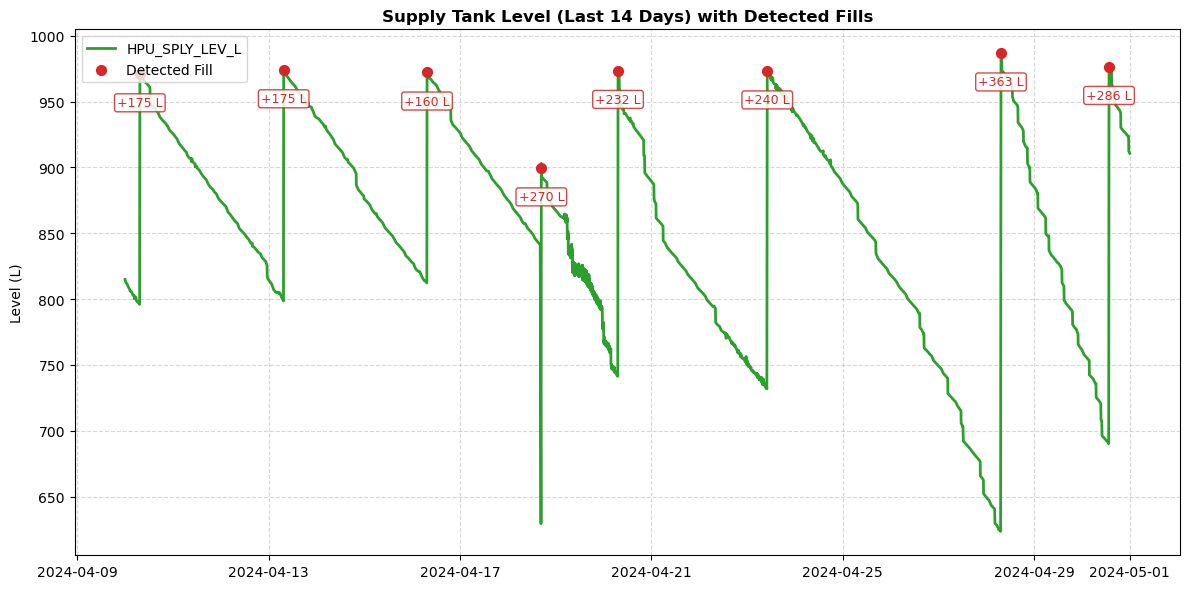

In [ ]:
df_all_otter = detect_fills_safe(
    df_all_otter,
    level_col="HPU_SPLY_LEV_L",
    min_event_litres=10.0,
    step_noise=0.5,
    max_gap="3min",
    max_step_litres=150.0,
    smooth_window="5min"
)
import matplotlib.pyplot as plt

# 1) Last 14 days
df14 = df_all_otter.last("21D")

# 2) One value per event end (combine duplicate timestamps safely)
ev_pos = df14.loc[df14["tank_fill_volume"] > 0, "tank_fill_volume"]
ev_per_ts = ev_pos.groupby(ev_pos.index).sum()        # <- use ev_pos.index
# (equivalently: ev_per_ts = ev_pos.groupby(level=0).sum())

# 3) Deduplicate level for plotting
level_u = df14["HPU_SPLY_LEV_L"].groupby(df14.index).last()

# 4) Align markers to level timestamps
ev_level = level_u.reindex(ev_per_ts.index).dropna()

# 5) Plot
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(level_u.index, level_u.values, color="#2ca02c", lw=2, label="HPU_SPLY_LEV_L")
ax.scatter(ev_level.index, ev_level.values, color="#d62728", s=50, zorder=5, label="Detected Fill")

for t, y in ev_level.items():
    vol = int(round(ev_per_ts.loc[t]))
    ax.annotate(f"+{vol} L", xy=(t, y), xytext=(0, -16), textcoords="offset points",
                ha="center", va="top", fontsize=9, color="#d62728",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#d62728", alpha=0.85))

ax.set_title("Supply Tank Level (Last 14 Days) with Detected Fills", weight="bold")
ax.set_ylabel("Level (L)")
ax.grid(True, ls="--", alpha=0.5)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
# Extract detected fills (non-zero volumes)
fill_events = df_all_otter.loc[df_all_otter["tank_fill_volume"] > 0, "tank_fill_volume"]

# Convert to a DataFrame for readability
fill_table = fill_events.reset_index()
fill_table.columns = ["Date Time of Fill", "Fill Volume (l)"]

# Show the last 5 fills
print(fill_table.tail(5))


import pandas as pd
pd.set_option("display.precision", 1)  # one decimal if you like
display(fill_table.tail(5))


       Date Time of Fill  Fill Volume (l)
1821 2024-04-18 16:50:00            270.0
1822 2024-04-20 07:19:00            231.7
1823 2024-04-23 10:10:00            240.0
1824 2024-04-28 07:25:00            363.0
1825 2024-04-30 13:36:00            286.2


,Date Time of Fill,Fill Volume (l)
1821,2024-04-18 16:50:00,270.0
1822,2024-04-20 07:19:00,231.7
1823,2024-04-23 10:10:00,240.0
1824,2024-04-28 07:25:00,363.0
1825,2024-04-30 13:36:00,286.2


Explore and analyse the fluid consumption

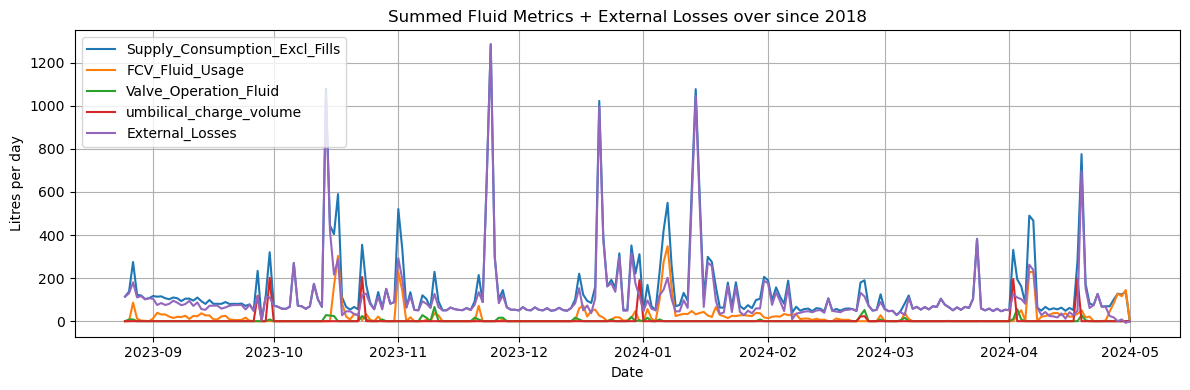

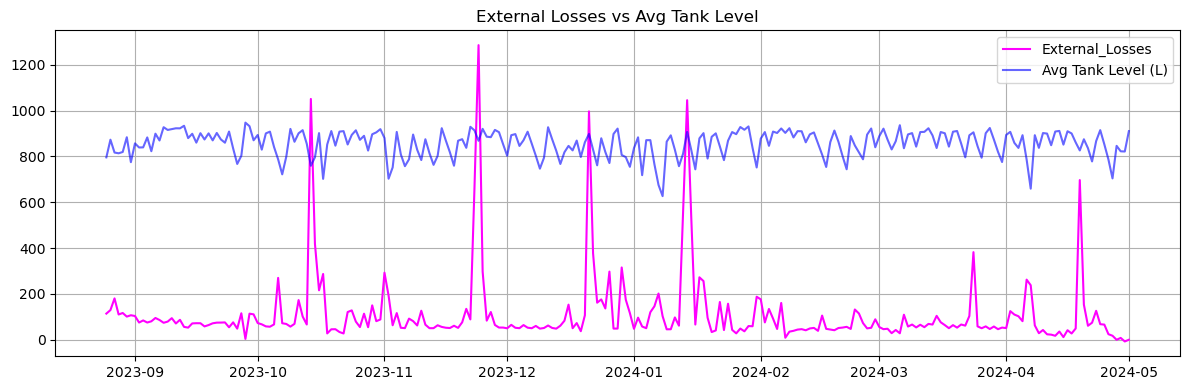

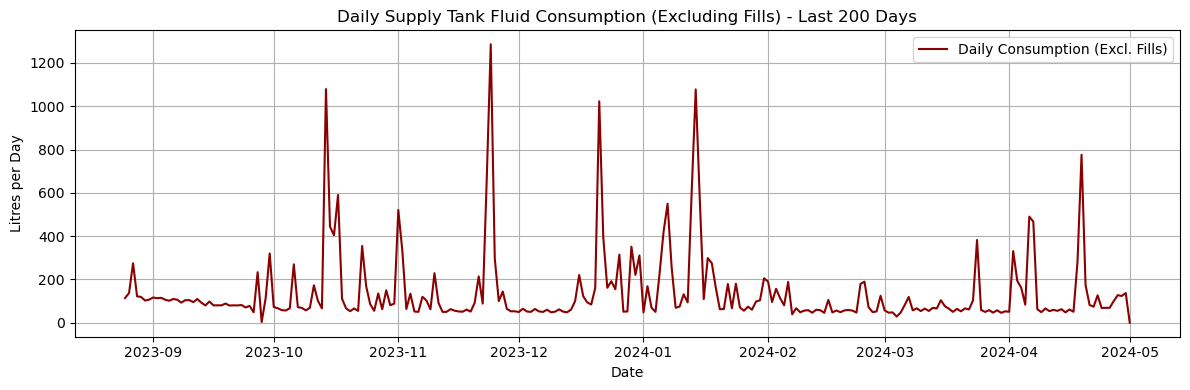

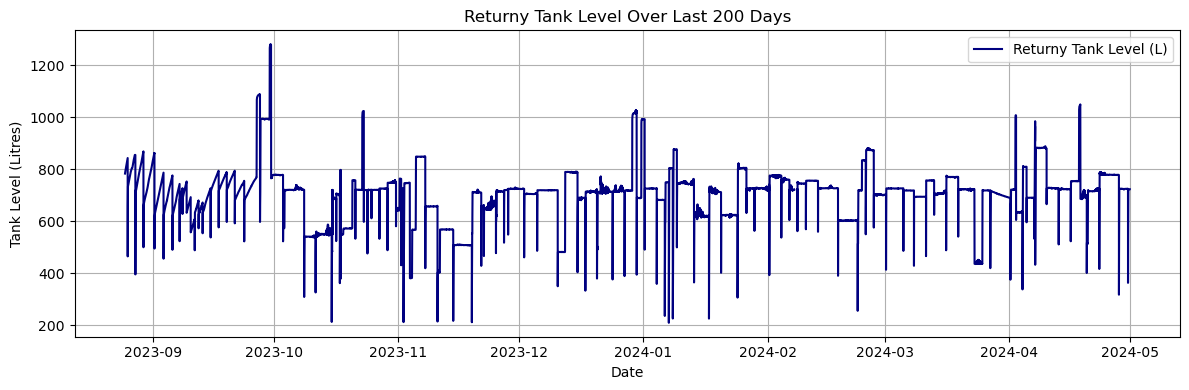

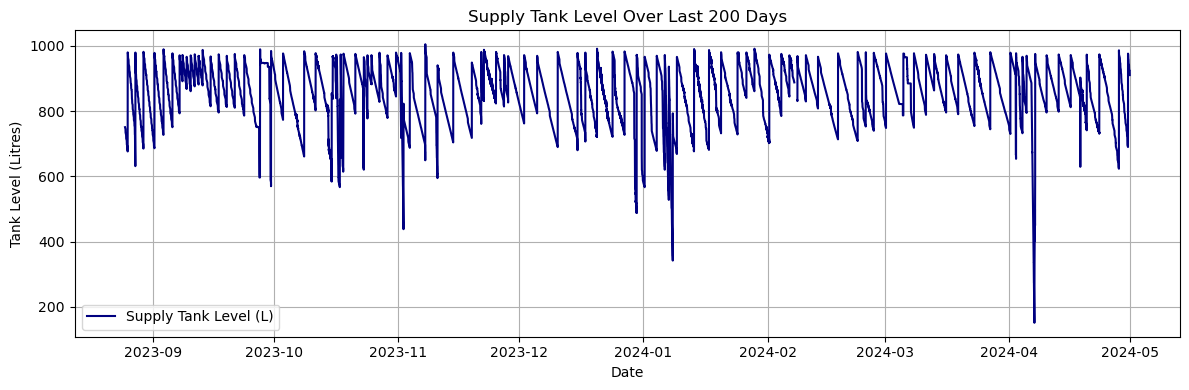

In [ ]:
# 0) Make sure your index is datetime and sorted UNSMOOTHED
df_all_otter.index = pd.to_datetime(df_all_otter.index)
df_all_otter.sort_index(inplace=True)

# 1) Restrict to the last 440 days
df_recent = df_all_otter.last('250D')

# 2) Hourly‐sum each metric (gives litres per hour)
daily = df_recent[[
    'Supply_Consumption_Excl_Fills',
    'FCV_Fluid_Usage',
    'Valve_Operation_Fluid',
    'umbilical_charge_volume'
]].resample('D').sum()

# 3) Compute External Losses = Total – (FCV + Valve + Umbilical)
daily['External_Losses'] = (
      daily['Supply_Consumption_Excl_Fills']
    - daily['FCV_Fluid_Usage']
    - daily['Valve_Operation_Fluid']
    - daily['umbilical_charge_volume']
)

# 4) Plot
plt.figure(figsize=(12, 4))
for col in ['Supply_Consumption_Excl_Fills', 'FCV_Fluid_Usage',
            'Valve_Operation_Fluid', 'umbilical_charge_volume',
            'External_Losses']:
    plt.plot(daily.index, daily[col], label=col)

plt.title("Summed Fluid Metrics + External Losses over since 2018")
plt.xlabel("Date")
plt.ylabel("Litres per day")
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

df_level = df_recent['HPU_SPLY_LEV_L'].resample('D').mean()

plt.figure(figsize=(12, 4))
plt.plot(daily.index, daily['External_Losses'], color='magenta', label='External_Losses')
plt.plot(df_level.index, df_level, color='blue', alpha=0.6, label='Avg Tank Level (L)')
plt.legend()
plt.grid()
plt.title("External Losses vs Avg Tank Level")
plt.tight_layout()
plt.show()

daily_consumption = df_recent['Supply_Consumption_Excl_Fills'].resample('D').sum()

# 5) Plot
plt.figure(figsize=(12, 4))
plt.plot(daily_consumption.index, daily_consumption, label='Daily Consumption (Excl. Fills)', color='darkred')
plt.title('Daily Supply Tank Fluid Consumption (Excluding Fills) - Last 200 Days')
plt.xlabel('Date')
plt.ylabel('Litres per Day')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.figure(figsize=(12, 4))
plt.plot(df_recent.index, df_recent['HPU_RET_LEV_L'], label='Returny Tank Level (L)', color='navy')
plt.title('Returny Tank Level Over Last 200 Days')
plt.xlabel('Date')
plt.ylabel('Tank Level (Litres)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 4))
plt.plot(df_recent.index, df_recent['HPU_SPLY_LEV_L'], label='Supply Tank Level (L)', color='navy')
plt.title('Supply Tank Level Over Last 200 Days')
plt.xlabel('Date')
plt.ylabel('Tank Level (Litres)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()





Smoothed Tank Levels Display

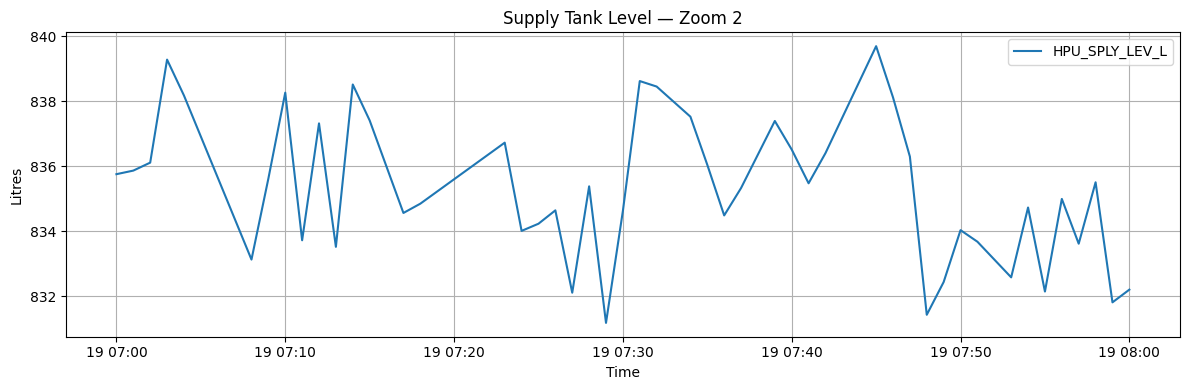

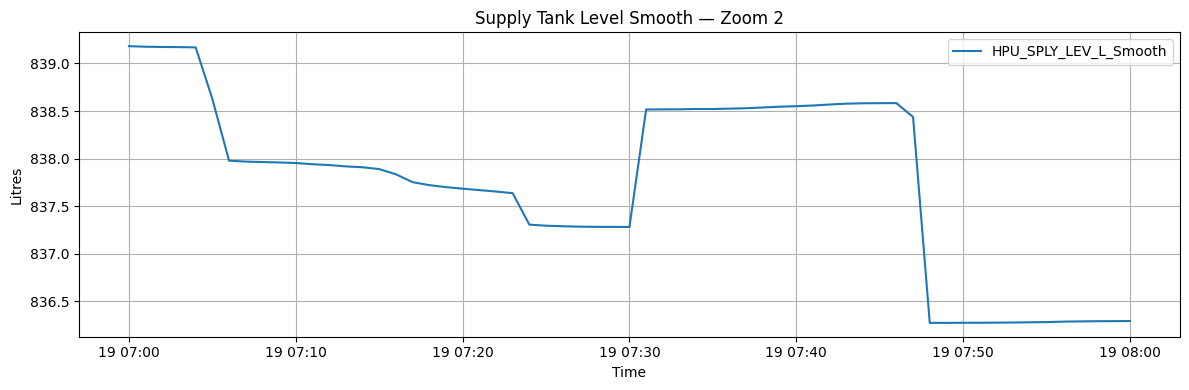

In [ ]:
# Pick the two noisy windows (UTC; adjust as needed)

win2 = ("2024-04-19 07:00", "2024-04-19 08:00")

def plot_zoom(df, col, start, end, title):
    z = df.loc[start:end]
    plt.figure(figsize=(12, 4))
    plt.plot(z.index, z[col], label=col)
    plt.title(title)
    plt.xlabel("Time"); plt.ylabel("Litres"); plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()

plot_zoom(df_recent, "HPU_SPLY_LEV_L", *win2, title="Supply Tank Level — Zoom 2")
plot_zoom(df_recent, "HPU_SPLY_LEV_L_Smooth", *win2, title="Supply Tank Level Smooth — Zoom 2")

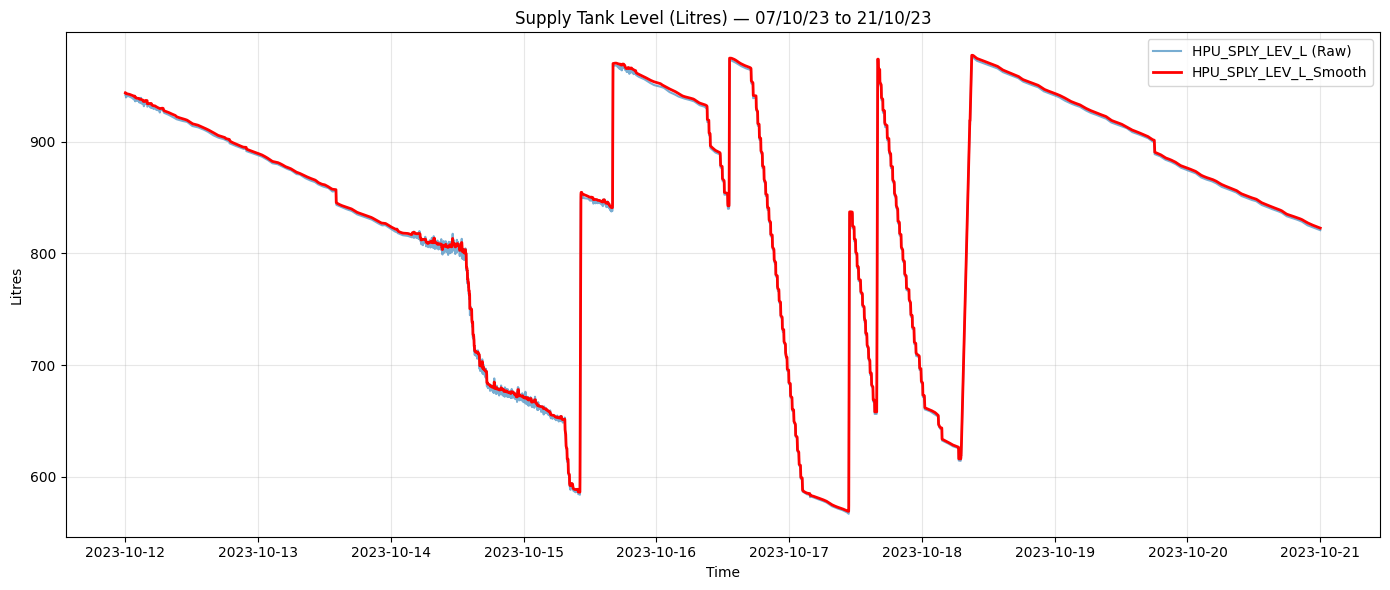

In [ ]:
start = pd.to_datetime("2023-10-12")
end   = pd.to_datetime("2023-10-21")

# Slice dataframe
df_range = df_all_otter.loc[start:end, ['HPU_SPLY_LEV_L', 'HPU_SPLY_LEV_L_Smooth']]

# Plot
plt.figure(figsize=(14,6))
plt.plot(df_range.index, df_range['HPU_SPLY_LEV_L'], label="HPU_SPLY_LEV_L (Raw)", alpha=0.6)
plt.plot(df_range.index, df_range['HPU_SPLY_LEV_L_Smooth'], label="HPU_SPLY_LEV_L_Smooth", linewidth=2, color="red")
plt.title("Supply Tank Level (Litres) — 07/10/23 to 21/10/23")
plt.xlabel("Time")
plt.ylabel("Litres")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

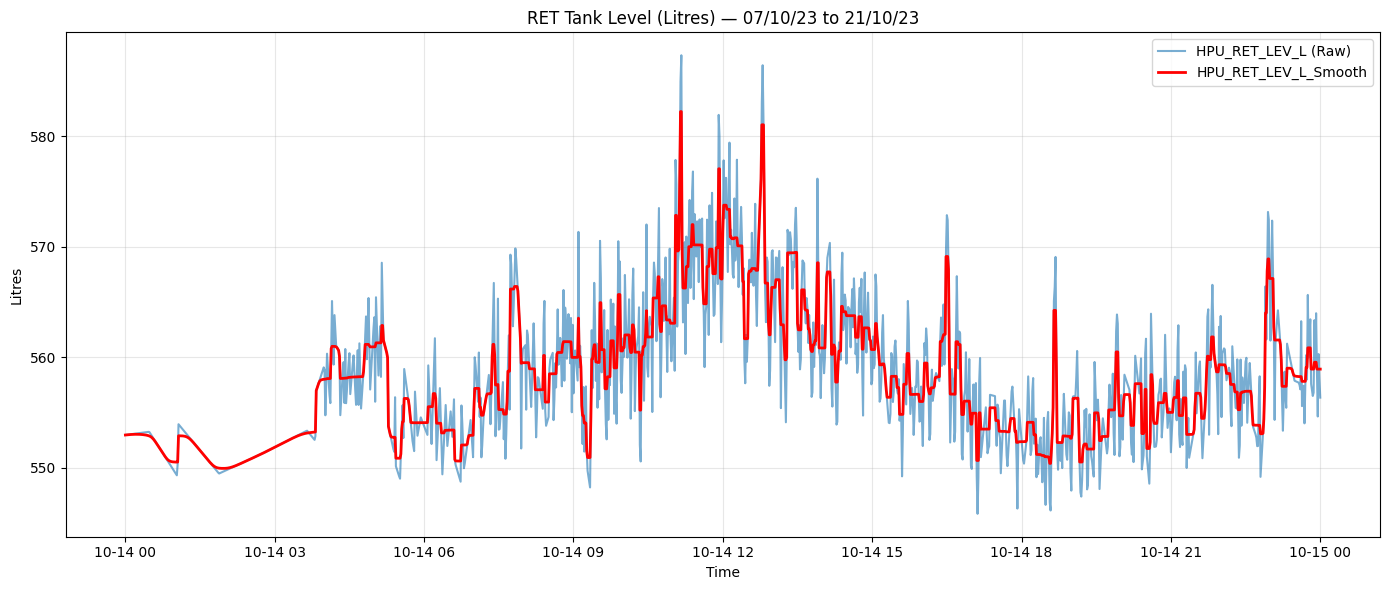

In [ ]:
start = pd.to_datetime("2023-10-14")
end   = pd.to_datetime("2023-10-15")

# Slice dataframe
df_range = df_all_otter.loc[start:end, ['HPU_RET_LEV_L', 'HPU_RET_LEV_L_Smooth']]

# Plot
plt.figure(figsize=(14,6))
plt.plot(df_range.index, df_range['HPU_RET_LEV_L'], label="HPU_RET_LEV_L (Raw)", alpha=0.6)
plt.plot(df_range.index, df_range['HPU_RET_LEV_L_Smooth'], label="HPU_RET_LEV_L_Smooth", linewidth=2, color="red")
plt.title("RET Tank Level (Litres) — 07/10/23 to 21/10/23")
plt.xlabel("Time")
plt.ylabel("Litres")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print(df_recent.columns.tolist())

['HPU_SPLY_LEV', 'HPU_RET_LEV', 'HPU_LP_A_SPLY', 'HPU_LP_B_SPLY', 'HPU_HP_A_SPLY', 'HPU_HP_B_SPLY', 'HPU_LPA_OUT', 'HPU_LPB_OUT', 'HPU_HPA_OUT', 'HPU_HPB_OUT', 'SCM1_LP_CONS', 'SCM1_HP_CONS', 'SCM1_RET', 'SCM2_LP_CONS', 'SCM2_RET', 'P3_PMV', 'P3_PWV', 'P3_AMV', 'P3_SCSSV', 'P3_PDV', 'P3_TDV', 'P1_PMV', 'P1_PWV', 'P1_AMV', 'P1_SCSSV', 'P1_PDV', 'P1_TDV', 'P2_PMV', 'P2_PWV', 'P2_AMV', 'P2_SCSSV', 'P2_PDV', 'P2_TDV', 'I1_PMV', 'I1_PWV', 'I1_AMV', 'I2_PMV', 'I2_PWV', 'I2_AMV', 'FCV_CPI', 'P1_PCV', 'P2_PCV', 'P3_PCV', 'I1_PCV', 'I2_PCV', 'MPMV_Inlet', 'Man_CI', 'SCM1_LP1_COV', 'SCM1_HP_COV', 'HPU_SPLY_LEV_B', 'HPU-RET_LEV_B', 'SCM2_LP1_COV', 'SCM2_HP_COV', 'SCM3_LP1_COV', 'SCM3_HP_COV', 'SCM4_LP1_COV', 'SCM4_HP_COV', 'SCM5_LP1_COV', 'SCM5_HP_COV', 'SCM3_LP_CONS', 'SCM3_HP_CONS', 'SCM3_RET', 'SCM4_LP_CONS', 'SCM4_HP_CONS', 'SCM4_RET', 'SCM5_LP_CONS', 'SCM5_HP_CONS', 'SCM5_RET', 'P1_PMV_OpenToClosed', 'P1_PMV_ClosedToOpen', 'P1_PWV_OpenToClosed', 'P1_PWV_ClosedToOpen', 'P1_AMV_OpenToClosed', 

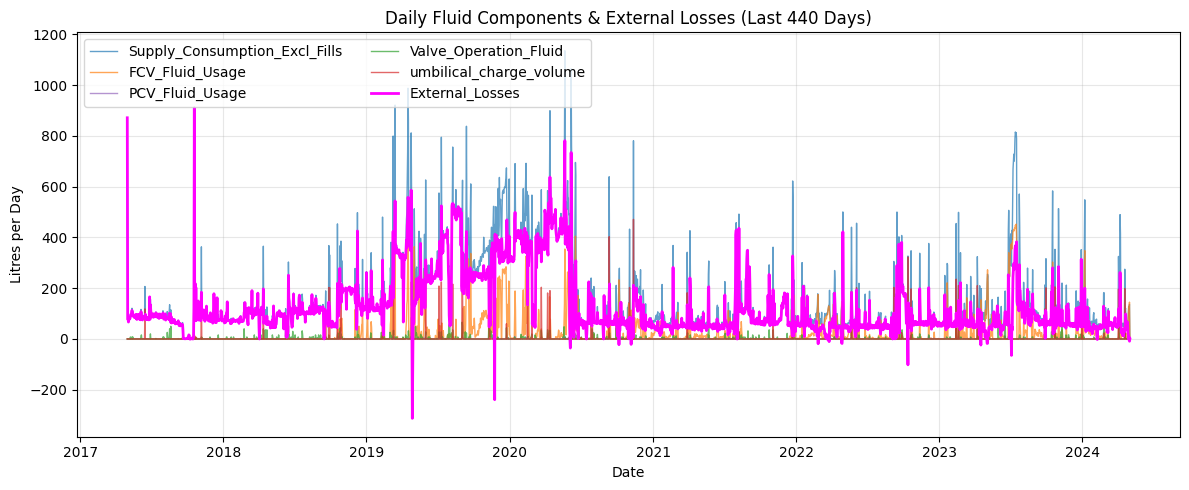

In [ ]:
# Display the external fluid losses. Investigate the highe losses from 2019 into 2020 before it returned

# 1) Ensure datetime index & sort
df_all_otter.index = pd.to_datetime(df_all_otter.index, errors='coerce')
df_all_otter.sort_index(inplace=True)

# 2) Slice to last 440 days
df_recent = df_all_otter.last('2755D')

# 3) Daily sums (L/day)
daily = df_recent[[
    'Supply_Consumption_Excl_Fills',
    'FCV_Fluid_Usage',
    'PCV_Fluid_Usage',                # <-- added PCV
    'Valve_Operation_Fluid',
    'umbilical_charge_volume'
]].resample('D').sum()

# 4) Compute External_Losses inline
daily['External_Losses'] = (
      daily['Supply_Consumption_Excl_Fills']
    - daily['FCV_Fluid_Usage']
    - daily['PCV_Fluid_Usage']        # <-- subtract PCV
    - daily['Valve_Operation_Fluid']
    - daily['umbilical_charge_volume']
)

# 5) Plot
plt.figure(figsize=(12, 5))

for col, color, lw, alpha in [
    ('Supply_Consumption_Excl_Fills',        'C0', 1, 0.7),
    ('FCV_Fluid_Usage',                'C1', 1, 0.7),
    ('PCV_Fluid_Usage',                'C4', 1, 0.7),  # PCV in C4
    ('Valve_Operation_Fluid',          'C2', 1, 0.7),
    ('umbilical_charge_volume','C3', 1, 0.7),
    ('External_Losses',                'magenta', 2, 1.0),
]:
    plt.plot(
        daily.index,
        daily[col],
        label=col,
        color=color,
        linewidth=lw,
        alpha=alpha
    )

plt.title("Daily Fluid Components & External Losses (Last 440 Days)")
plt.xlabel("Date")
plt.ylabel("Litres per Day")
plt.legend(loc='upper left', ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


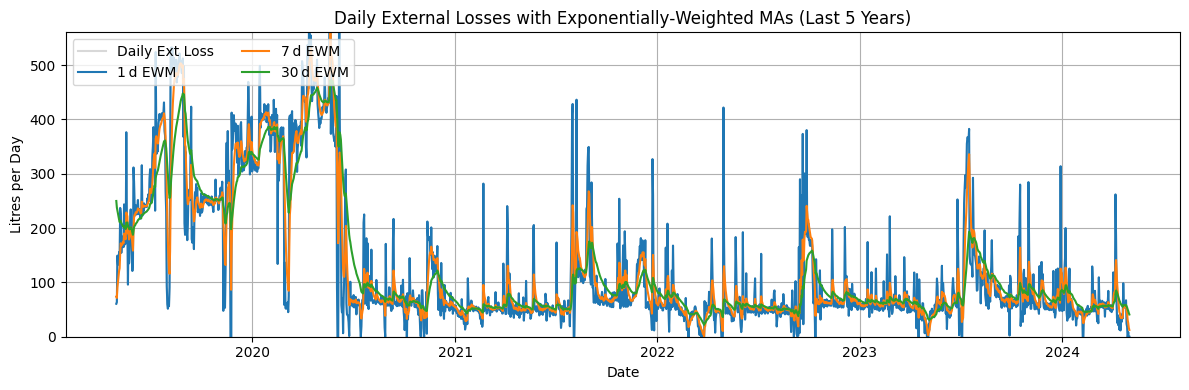

In [ ]:
#  Build  daily Exponentially Weighted Moving Averages (EWM) with spans 1, 7, and 30 days: (L/day) 
#smooth out day-to-day jitter so you can see the underlying pattern.
#7-day EWM: short-term/weekly trend; 
#30-day EWM: medium-term/monthly baseline; 


#    If you haven’t already, do:
df_all_otter.index = pd.to_datetime(df_all_otter.index, errors='coerce')
daily = (
    df_all_otter['External_Losses']
      .resample('D')
      .sum()
      .to_frame(name='Ext_Loss_L_per_day')
)

# 2) Compute EWMs with spans of 1, 7, and 30 days
for span in [1, 7, 30]:
    daily[f'EWM_{span}d'] = (
        daily['Ext_Loss_L_per_day']
             .ewm(span=span, adjust=False)
             .mean()
    )

# 3) Zoom into the last 5 years
cutoff = daily.index.max() - pd.DateOffset(years=5)
d5 = daily.loc[cutoff:]

# 4) Plot
plt.figure(figsize=(12, 4))

# raw daily loss
plt.plot(
    d5.index,
    d5['Ext_Loss_L_per_day'],
    color='gray',
    alpha=0.3,
    label='Daily Ext Loss'
)

# EWM curves
colors = ['C0','C1','C2']
for span, c in zip([1, 7, 30], colors):
    plt.plot(
        d5.index,
        d5[f'EWM_{span}d'],
        color=c,
        linewidth=1.5,
        label=f'{span} d EWM'
    )

plt.title("Daily External Losses with Exponentially‑Weighted MAs (Last 5 Years)")
plt.xlabel("Date")
plt.ylabel("Litres per Day")

# set y‑limit to just above the 99th percentile of raw daily loss
upper = d5['Ext_Loss_L_per_day'].quantile(0.99) * 1.1
plt.ylim(0, upper)

plt.legend(loc='upper left', ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()


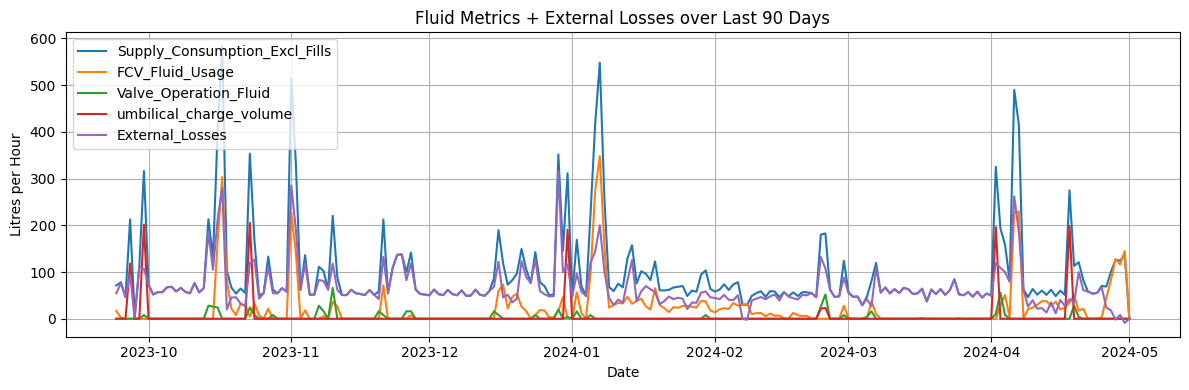

In [ ]:
df_recent = df_all_otter.last('220D')

# 2) Hourly‐sum each metric (gives litres per hour)
daily = df_recent[[
    'Supply_Consumption_Excl_Fills',
    'FCV_Fluid_Usage',
    'Valve_Operation_Fluid',
    'umbilical_charge_volume'
]].resample('D').sum()

# 3) Compute External Losses = Total – (FCV + Valve + Umbilical)
daily['External_Losses'] = (
      daily['Supply_Consumption_Excl_Fills']
    - daily['FCV_Fluid_Usage']
    - daily['Valve_Operation_Fluid']
    - daily['umbilical_charge_volume']
)

# 4) Plot
plt.figure(figsize=(12, 4))
for col in ['Supply_Consumption_Excl_Fills', 'FCV_Fluid_Usage',
            'Valve_Operation_Fluid', 'umbilical_charge_volume',
            'External_Losses']:
    plt.plot(daily.index, daily[col], label=col)

plt.title("Fluid Metrics + External Losses over Last 90 Days")
plt.xlabel("Date")
plt.ylabel("Litres per Hour")
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

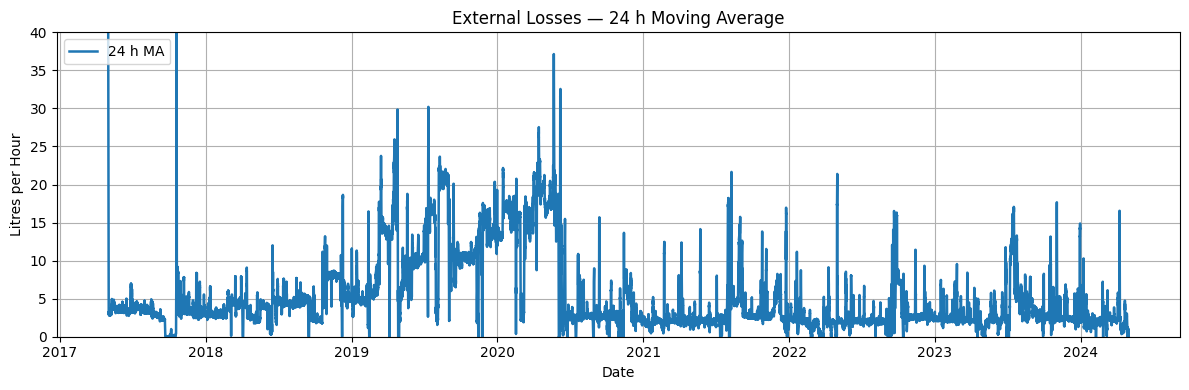

In [ ]:
hourly = df_all_otter[[
    'Supply_Consumption_Excl_Fills',
    'FCV_Fluid_Usage',
    'Valve_Operation_Fluid',
    'umbilical_charge_volume'
]].resample('H').sum()

hourly['External_Losses'] = (
      hourly['Supply_Consumption_Excl_Fills']
    - hourly['FCV_Fluid_Usage']
    - hourly['Valve_Operation_Fluid']
    - hourly['umbilical_charge_volume']
)

# 24h moving average only
hourly['MA_24h'] = hourly['External_Losses'].rolling(24, min_periods=1).mean()

plt.figure(figsize=(12, 4))
plt.plot(hourly.index, hourly['MA_24h'], linewidth=1.8, label='24 h MA')

plt.title("External Losses — 24 h Moving Average")
plt.xlabel("Date")
plt.ylabel("Litres per Hour")
plt.ylim(0, 40)          # y-range 0..40
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


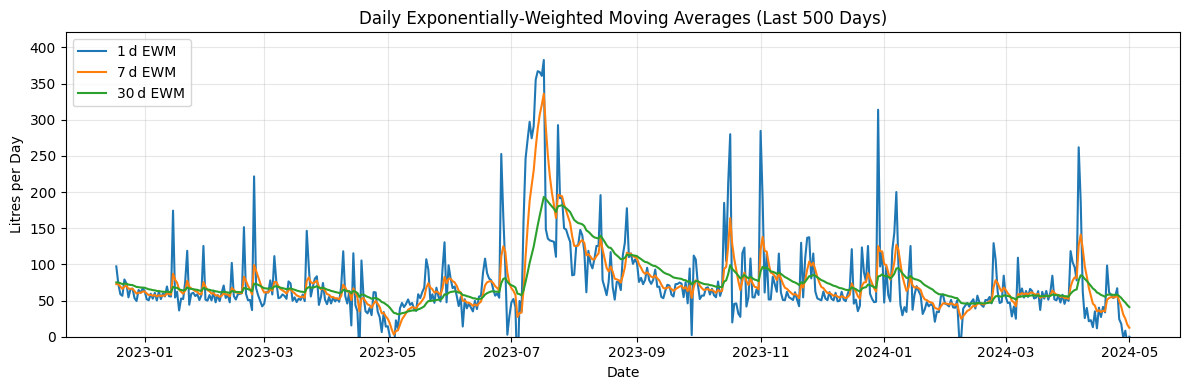

In [ ]:
# 1) Ensure datetime index & sort
df_all_otter.index = pd.to_datetime(df_all_otter.index, errors='coerce')
df_all_otter.sort_index(inplace=True)

# 2) Slice to the last 500 days
df500 = df_all_otter.last('500D')

# 3) Resample the EWM columns to daily (so you get one point per day)
daily_ewm = df500[['EWM_1d','EWM_7d','EWM_30d']].resample('D').last()

# 4) Plot
plt.figure(figsize=(12, 4))
for span, col, color in [
    (1,  'EWM_1d',  'C0'),
    (7,  'EWM_7d',  'C1'),
    (30, 'EWM_30d','C2'),
]:
    plt.plot(
        daily_ewm.index,
        daily_ewm[col],
        color=color,
        linewidth=1.5,
        label=f'{span} d EWM'
    )

plt.title("Daily Exponentially‑Weighted Moving Averages (Last 500 Days)")
plt.xlabel("Date")
plt.ylabel("Litres per Day")
plt.ylim(0, daily_ewm.max().max()*1.1)  # give 10% headroom
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
del df500

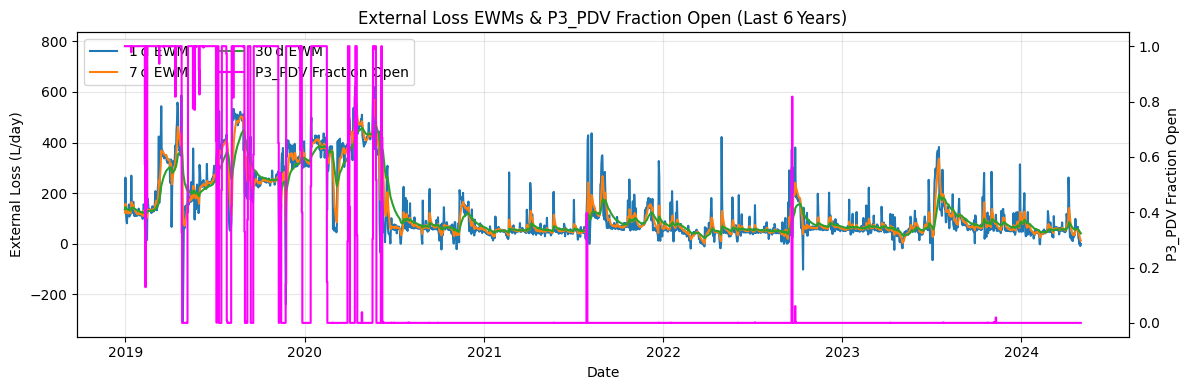

In [ ]:
# Show the data losses against a P3 well Production diverter valve (this valve had a leak associated with it ). This valve caused the elevated fluid usages from 2019 to 2020 when in Open position

# 0) Make sure your main DF is datetime‑indexed & sorted
df_all_otter.index = pd.to_datetime(df_all_otter.index, errors='coerce')
df_all_otter.sort_index(inplace=True)

# 1) Create a numeric “fraction open” series from your state column
#    Map 'OPEN' or 'FAULT' → 1.0, everything else (e.g. 'CLOSED') → 0.0
df_all_otter['P3_PDV_num'] = (
    df_all_otter['P3_PDV']
    .map({'OPEN': 1.0, 'FAULT': 1.0, 'CLOSED': 0.0})
    .fillna(0.0)
)

# 2) Slice the last 6 years of data
df6y = df_all_otter.last('6Y')

# 3) Resample your EWMs to daily (take the last value each day)
daily_ewm = df6y[['EWM_1d','EWM_7d','EWM_30d']].resample('D').last()

# 4) Build daily P3_PDV fraction‑open, aligned to the same dates
daily_p3 = (
    df_all_otter['P3_PDV_num']
    .resample('D')
    .mean()
    .loc[daily_ewm.index]
)

# 5) Plot
fig, ax1 = plt.subplots(figsize=(12, 4))

# — left axis: EWMs
for span, col in zip([1,7,30], ['EWM_1d','EWM_7d','EWM_30d']):
    ax1.plot(
        daily_ewm.index,
        daily_ewm[col],
        linewidth=1.5,
        label=f'{span} d EWM'
    )

ax1.set_ylabel("External Loss (L/day)")
ax1.set_xlabel("Date")
ax1.set_title("External Loss EWMs & P3_PDV Fraction Open (Last 6 Years)")
ax1.grid(alpha=0.3)

# — right axis: P3_PDV fraction open
ax2 = ax1.twinx()
ax2.step(
    daily_p3.index,
    daily_p3.values,
    where='mid',
    color='magenta',    # ← here!
    linewidth=1.5,
    label='P3_PDV Fraction Open'
)
ax2.set_ylabel("P3_PDV Fraction Open")
ax2.set_ylim(-0.05, 1.05)

# — Combine legends
h1,l1 = ax1.get_legend_handles_labels()
h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left', ncol=2)

# — Beautify dates
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(
    mdates.ConciseDateFormatter(ax1.xaxis.get_major_locator())
)

plt.tight_layout()
plt.show()

del df6y

Derive LP and HP Pumps Runtime and run duration. 

In [ ]:
# Derive pump run time from LP and HP Pressure.
# A positive rate of change of pressure as “pump is running.” Locate the timestamps where that “running” state turns on (start) and off (stop), pairs them up, and keeps only runs at least min_run_minutes long.
# This takes many hours to run, save to csv file so can be uploaded into the DF pipeline


def detect_pump_runs(df, pressure_col, min_run_minutes=2):
    """
    Detect pump run start/stop times based on positive pressure rate of change.
    Returns a list of run intervals.
    """
    # Calculate rate of change
    pressure_roc = df[pressure_col].diff()

    # Flag where pressure is increasing (pump on)
    running = pressure_roc > 0

    # Identify rising edges (start) and falling edges (stop)
    starts = (running & ~running.shift(1, fill_value=False)).astype(int)
    stops = (~running & running.shift(1, fill_value=False)).astype(int)

    run_intervals = []
    start_time = None

    for timestamp, is_start in starts[starts == 1].items():
        start_time = timestamp

        # Find the next stop after this start
        stop_candidates = stops[stops.index > timestamp]
        stop_time = stop_candidates[stop_candidates == 1].index.min()

        if pd.notnull(stop_time):
            # Filter out too short runs
            duration = (stop_time - start_time).total_seconds() / 60.0
            if duration >= min_run_minutes:
                run_intervals.append((start_time, stop_time))

    return run_intervals

# Pressure columsn to derive pump runs
pump_columns = {
    'LP_Pump_A': 'HPU_LP_A_SPLY',
    'LP_Pump_B': 'HPU_LP_B_SPLY',
    'HP_Pump_A': 'HPU_HP_A_SPLY',
    'HP_Pump_B': 'HPU_HP_B_SPLY',
}

results = {}

for name, col in pump_columns.items():
    intervals = detect_pump_runs(df_all_otter, col)
    results[name] = intervals
    print(f"\n{name}: {len(intervals)} runs")
    for i, (start, stop) in enumerate(intervals[:5], 1):  # Show first 5
        duration = (stop - start).total_seconds() / 60
        print(f"  Run {i}: {start} to {stop} ({duration:.1f} mins)")

# Optional: Save all intervals to a DataFrame
all_runs = []
for pump, runs in results.items():
    for start, stop in runs:
        all_runs.append({
            "Pump": pump,
            "Start Time": start,
            "Stop Time": stop,
            "Duration (min)": (stop - start).total_seconds() / 60.0
        })

df_pump_runs = pd.DataFrame(all_runs)
df_pump_runs.sort_values("Start Time", inplace=True)


LP_Pump_A: 28001 runs
  Run 1: 2017-05-01 00:27:00 to 2017-05-01 00:29:00 (2.0 mins)
  Run 2: 2017-05-01 00:54:00 to 2017-05-01 00:57:00 (3.0 mins)
  Run 3: 2017-05-01 01:21:00 to 2017-05-01 01:24:00 (3.0 mins)
  Run 4: 2017-05-01 01:49:00 to 2017-05-01 01:52:00 (3.0 mins)
  Run 5: 2017-05-01 02:16:00 to 2017-05-01 02:19:00 (3.0 mins)

LP_Pump_B: 28012 runs
  Run 1: 2017-05-01 00:27:00 to 2017-05-01 00:29:00 (2.0 mins)
  Run 2: 2017-05-01 00:54:00 to 2017-05-01 00:57:00 (3.0 mins)
  Run 3: 2017-05-01 01:21:00 to 2017-05-01 01:24:00 (3.0 mins)
  Run 4: 2017-05-01 01:49:00 to 2017-05-01 01:52:00 (3.0 mins)
  Run 5: 2017-05-01 02:16:00 to 2017-05-01 02:19:00 (3.0 mins)

HP_Pump_A: 72746 runs
  Run 1: 2017-05-01 00:12:00 to 2017-05-01 00:15:00 (3.0 mins)
  Run 2: 2017-05-01 00:55:00 to 2017-05-01 00:57:00 (2.0 mins)
  Run 3: 2017-05-01 01:37:00 to 2017-05-01 01:40:00 (3.0 mins)
  Run 4: 2017-05-01 02:19:00 to 2017-05-01 02:21:00 (2.0 mins)
  Run 5: 2017-05-01 03:01:00 to 2017-05-01 03:04:

In [ ]:
# Save the pump runtimes into a csv to allow data to be loaded into dataframe quickly
df_pump_runs2.to_csv("pump_run_events2.csv", index=False)
print(df_pump_runs2.tail())
print(df_pump_runs2.info())
print(df_pump_runs2.describe())


Determine the **systems baseline fluid usage**. 
This is where there is no demand, no operation and system is idle for at least a 12 hour period. During this period calculate a system baseline in litres per day

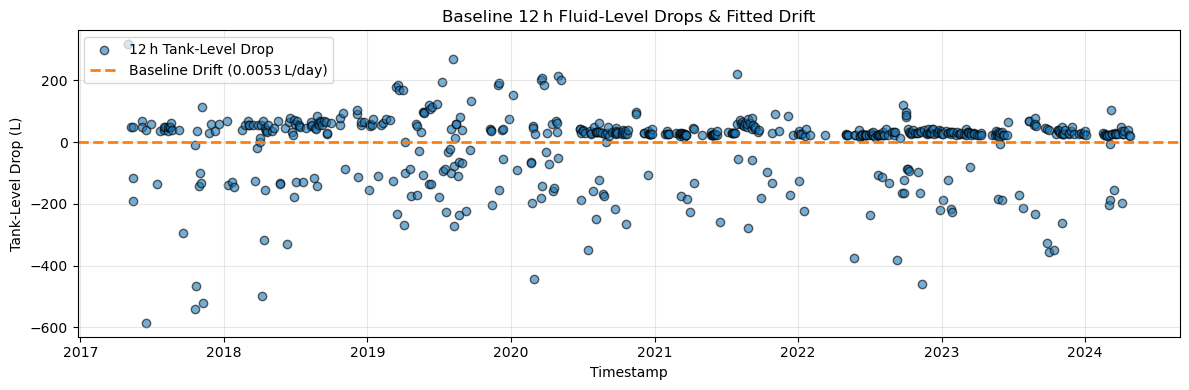

In [ ]:
# 1) Extract rows where a baseline drop was recorded
starts = df_all_otter.dropna(subset=['baseline_drop_L'])

# 2) Get the unique drift value (same on every row)
drift = df_all_otter['baseline_drift_L_per_day'].iloc[0]

# 3) Plot
fig, ax = plt.subplots(figsize=(12, 4))

# Scatter the 12 h drops at their start timestamps
ax.scatter(
    starts.index,
    starts['baseline_drop_L'],
    alpha=0.6,
    edgecolor='k',
    label='12 h Tank‑Level Drop'
)

# Draw a horizontal line for the drift (L/day)
ax.axhline(
    y=drift,
    color='C1',
    linestyle='--',
    linewidth=2,
    label=f"Baseline Drift ({drift:.4f} L/day)"
)

# 4) Labels & grid
ax.set_title("Baseline 12 h Fluid‑Level Drops & Fitted Drift")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Tank‑Level Drop (L)")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# 5) Nice date formatting
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

plt.tight_layout()
plt.show()


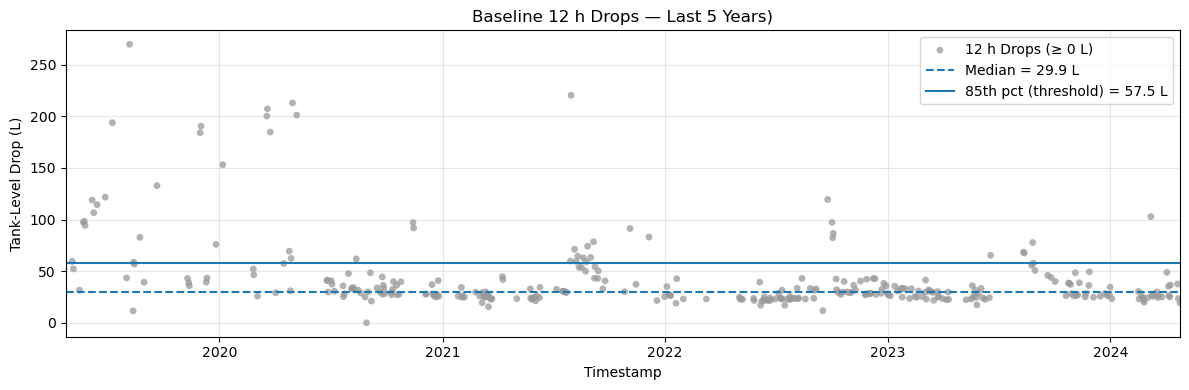

Window: 2019-04-24 → 2024-04-24
Median = 29.86 L | 85th pct = 57.51 L 


In [ ]:


# --- 1) Limit to last 4 years ) ---
window_end   = starts.index.max()
window_start = window_end - pd.DateOffset(years=5)
win = starts.loc[window_start:window_end].copy()

# --- 2) Use ONLY non-negative drops within the window ---
drops_all = win['baseline_drop_L']
drops = drops_all[drops_all >= 0]

# --- 3) Percentiles within the 4-year, n
pct50 = drops.quantile(0.50)
pct85 = drops.quantile(0.85)
pct95 = drops.quantile(0.95)

# Set your threshold line:
# threshold_L = 59.0
threshold_L = pct90  # <- change to 59.0 to hard-set

# --- 4) Axes limits to FULL range in the window ---
x_min, x_max = window_start, window_end
y_min, y_max = drops.min(), drops.max()
y_pad = max(1.0, 0.05 * (y_max - y_min))  # 5% padding or at least 1 L

# --- 5) Plot ---
fig, ax = plt.subplots(figsize=(12, 4))

ax.scatter(
    drops.index,
    drops.values,
    s=24,
    alpha=0.75,
    edgecolor='none',
    label='12 h Drops (≥ 0 L)',
    color='0.6'
)

# Reference lines
ax.axhline(pct50,       linestyle='--', label=f'Median = {pct50:.1f} L')
ax.axhline(threshold_L, linestyle='-',  label=f'85th pct (threshold) = {threshold_L:.1f} L')
#ax.axhline(pct95,       linestyle='--', label=f'95th pct = {pct95:.1f} L')

# Labels, axes, formatting
ax.set_title("Baseline 12 h Drops — Last 5 Years)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Tank-Level Drop (L)")
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min - y_pad, y_max + y_pad)

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

print(f"Window: {x_min.date()} → {x_max.date()}")
print(f"Median = {pct50:.2f} L | 85th pct = {pct85:.2f} L ")


2017: Median drop = 39.44 L
2018: Median drop = 48.32 L
2019: Median drop = 31.73 L
2020: Median drop = 29.22 L
2021: Median drop = 26.93 L
2022: Median drop = 23.89 L
2023: Median drop = 26.15 L
2024: Median drop = 24.69 L



A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


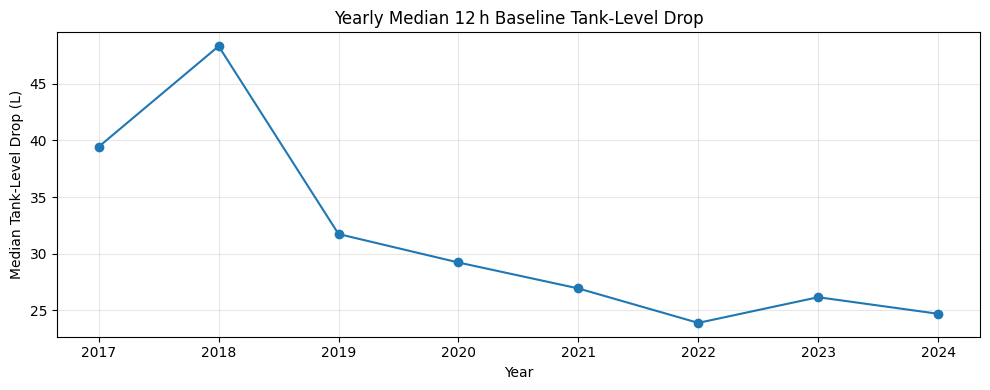

In [ ]:
# ---Determien the average annual baselien each year for the data set

starts['year'] = pd.to_datetime(starts.index).year

# --- 2) Group by year and compute the median drop ---
yearly_median = (
    starts
    .groupby('year')['baseline_drop_L']
    .median()
    .reset_index(name='median_drop')
)

# --- 3) Print out the results ---
for yr, md in zip(yearly_median['year'], yearly_median['median_drop']):
    print(f"{yr}: Median drop = {md:.2f} L")

# --- 4) Plot the yearly medians ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    yearly_median['year'],
    yearly_median['median_drop'],
    marker='o',
    linestyle='-'
)

# Labels, grid, title
ax.set_title("Yearly Median 12 h Baseline Tank‑Level Drop")
ax.set_xlabel("Year")
ax.set_ylabel("Median Tank‑Level Drop (L)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
## Remove all temp dataframes to reduce memory use and avoid crashes

for var_name in dir():
    var = globals()[var_name]
    if isinstance(var, pd.DataFrame):
        size_mb = sys.getsizeof(var) / (1024 ** 2)
        print(f"{var_name:30} {var.shape}  {size_mb:.2f} MB")


clean                          (366, 186)  0.92 MB
cum                            (4801, 3)  0.15 MB
d                              (3398347, 2)  77.78 MB
d5                             (1828, 4)  0.07 MB
daily                          (221, 5)  0.01 MB
daily_counts                   (241, 4)  0.01 MB
daily_ewm                      (1949, 3)  0.06 MB
df_all_otter                   (3682088, 186)  9315.78 MB
df_range                       (1441, 2)  0.03 MB
df_recent                      (316800, 185)  792.18 MB
hourly                         (61369, 7)  3.75 MB
hp_valve_trend                 (2558, 2)  0.06 MB
lp5_valve_trend                (200, 2)  0.00 MB
slopes                         (3682088, 2)  84.28 MB
starts                         (518, 187)  1.30 MB
valve_counts                   (200, 2)  0.00 MB
yearly_median                  (8, 2)  0.00 MB


In [ ]:
import gc
gc.collect()


189516

Explore and Analyse the **LP and HP Pump runtime** frequency (derived previosuly in notebook from pressure sensors). 
Elevated usage will results

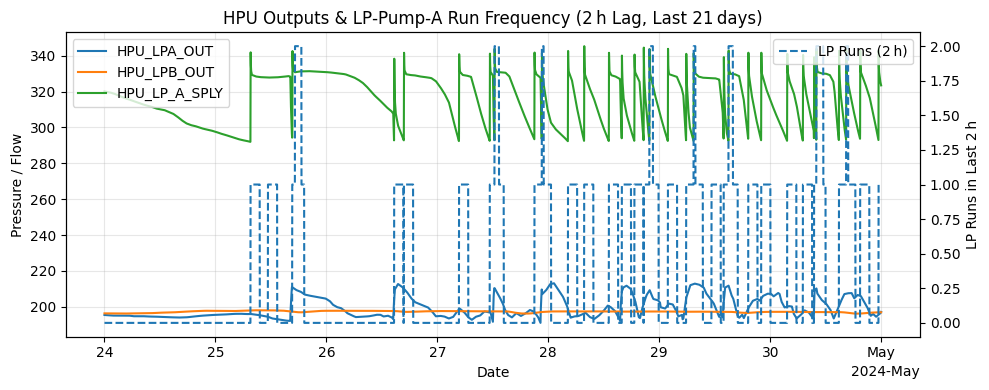

In [ ]:


# --- 1) Prepare df_all_otter in‑place (no full copy) ---
df_all_otter.index = pd.to_datetime(df_all_otter.index, errors='coerce')
df_all_otter.sort_index(inplace=True)

# --- 2) Compute LP_Runs_2h on the full series (in‑place) ---
# shift by 120 min (2 h) to get runs started in the last 2 h
df_all_otter['LP_Runs_2h'] = (
    df_all_otter['Cum_LP_Pump_A_Run_Count']
    - df_all_otter['Cum_LP_Pump_A_Run_Count'].shift(120)
).fillna(0)

# --- 3) Slice out just the last 21 days and copy that small chunk ---
end   = df_all_otter.index.max()
start = end - pd.DateOffset(days=7)
df21d = df_all_otter.loc[start:end].copy()

# --- 4) Plot HPU outputs + 2 h run frequency on this small slice ---
fig, ax1 = plt.subplots(figsize=(10, 4))

# Left axis: HPU signals
ax1.plot(df21d.index, df21d['HPU_LPA_OUT'],   label='HPU_LPA_OUT')
ax1.plot(df21d.index, df21d['HPU_LPB_OUT'],   label='HPU_LPB_OUT')
ax1.plot(df21d.index, df21d['HPU_LP_A_SPLY'], label='HPU_LP_A_SPLY')
ax1.set_xlabel('Date')
ax1.set_ylabel('Pressure / Flow')
ax1.legend(loc='upper left')

# Right axis: LP runs in last 2 h
ax2 = ax1.twinx()
ax2.plot(
    df21d.index,
    df21d['LP_Runs_2h'],
    label='LP Runs (2 h)',
    linestyle='--'
)
ax2.set_ylabel('LP Runs in Last 2 h')
ax2.legend(loc='upper right')

# Title, grid, date formatting
plt.title('HPU Outputs & LP‑Pump‑A Run Frequency (2 h Lag, Last 21 days)')
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(
    mdates.ConciseDateFormatter(ax1.xaxis.get_major_locator())
)

fig.tight_layout()
plt.show()


KeyError: 'LP_pump_state'

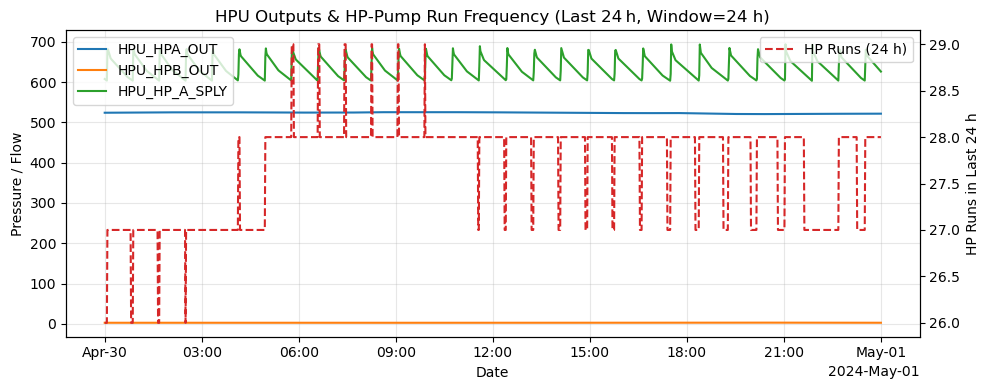

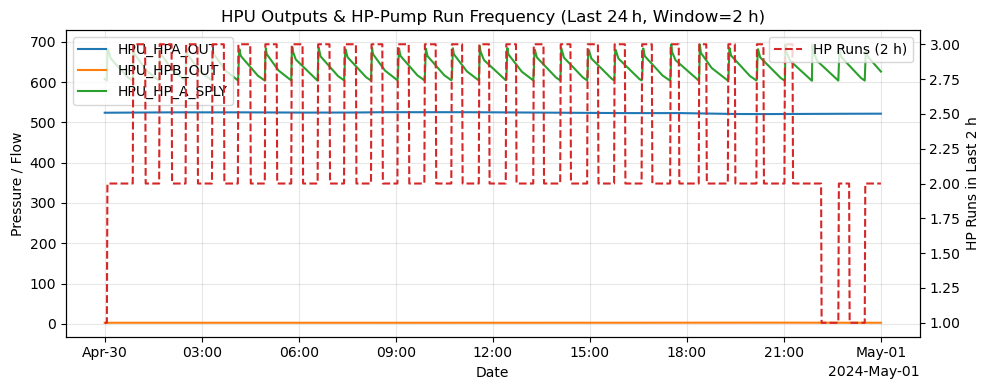

In [ ]:

# 0) Ensure df_all_otter is datetime‑indexed & sorted (do this just once)
df_all_otter.index = pd.to_datetime(df_all_otter.index, errors='coerce')
df_all_otter.sort_index(inplace=True)

# 1) Make sure the two HP‑run‐count lags exist
#    (if you already ran the LP version, just mirror it for HP)
df_all_otter['HP_Runs_24h'] = (
    df_all_otter['Cum_HP_Pump_A_Run_Count']
    - df_all_otter['Cum_HP_Pump_A_Run_Count'].shift(1440)
).fillna(0)

df_all_otter['HP_Runs_2h'] = (
    df_all_otter['Cum_HP_Pump_A_Run_Count']
    - df_all_otter['Cum_HP_Pump_A_Run_Count'].shift(120)
).fillna(0)

# 2) Slice out just the last 24 h (tiny chunk, no MemoryError)
end   = df_all_otter.index.max()
start = end - pd.DateOffset(days=1)
df1d  = df_all_otter.loc[start:end].copy()

# 3) Plot both 24 h & 2 h on twin axes
windows = [
    ('24 h', 'HP_Runs_24h'),
    ('2 h',  'HP_Runs_2h' )
]

for label, run_col in windows:
    fig, ax1 = plt.subplots(figsize=(10, 4))

    # Left axis: HPU high-pressure outputs
    ax1.plot(df1d.index, df1d['HPU_HPA_OUT'],    label='HPU_HPA_OUT')
    ax1.plot(df1d.index, df1d['HPU_HPB_OUT'],    label='HPU_HPB_OUT')
    ax1.plot(df1d.index, df1d['HPU_HP_A_SPLY'],  label='HPU_HP_A_SPLY')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Pressure / Flow')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax1.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(ax1.xaxis.get_major_locator())
    )

    # Right axis: HP‑pump start counts
    ax2 = ax1.twinx()
    ax2.plot(
        df1d.index,
        df1d[run_col],
        linestyle='--',
        color='tab:red',
        label=f'HP Runs ({label})'
    )
    ax2.set_ylabel(f'HP Runs in Last {label}')
    ax2.legend(loc='upper right')

    plt.title(f'HPU Outputs & HP‑Pump Run Frequency (Last 24 h, Window={label})')
    fig.tight_layout()
    plt.show()


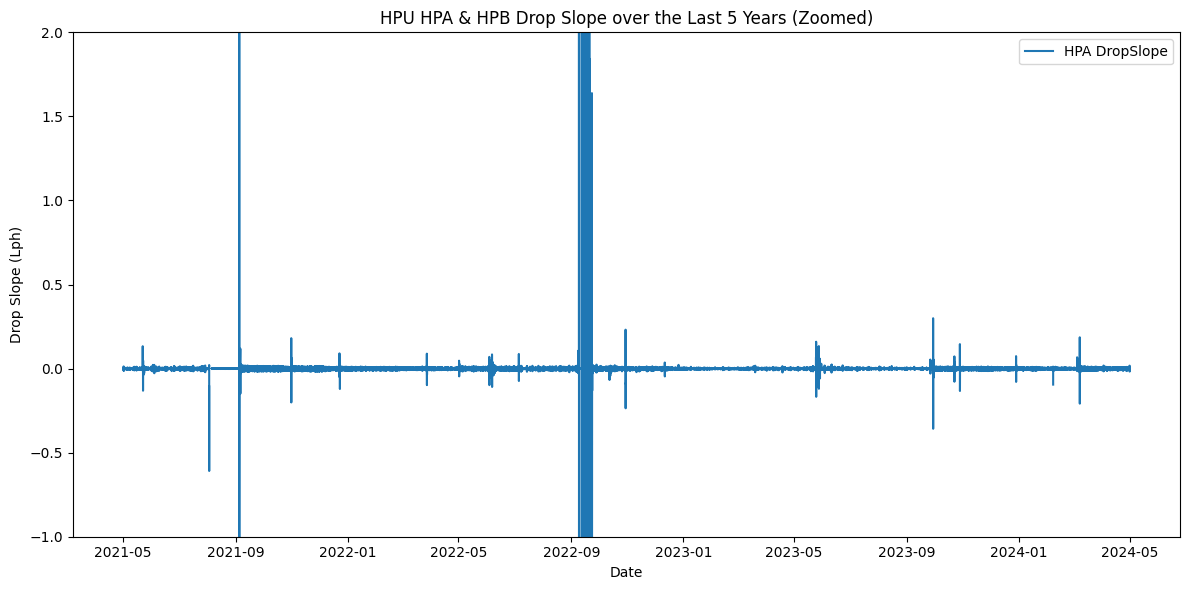

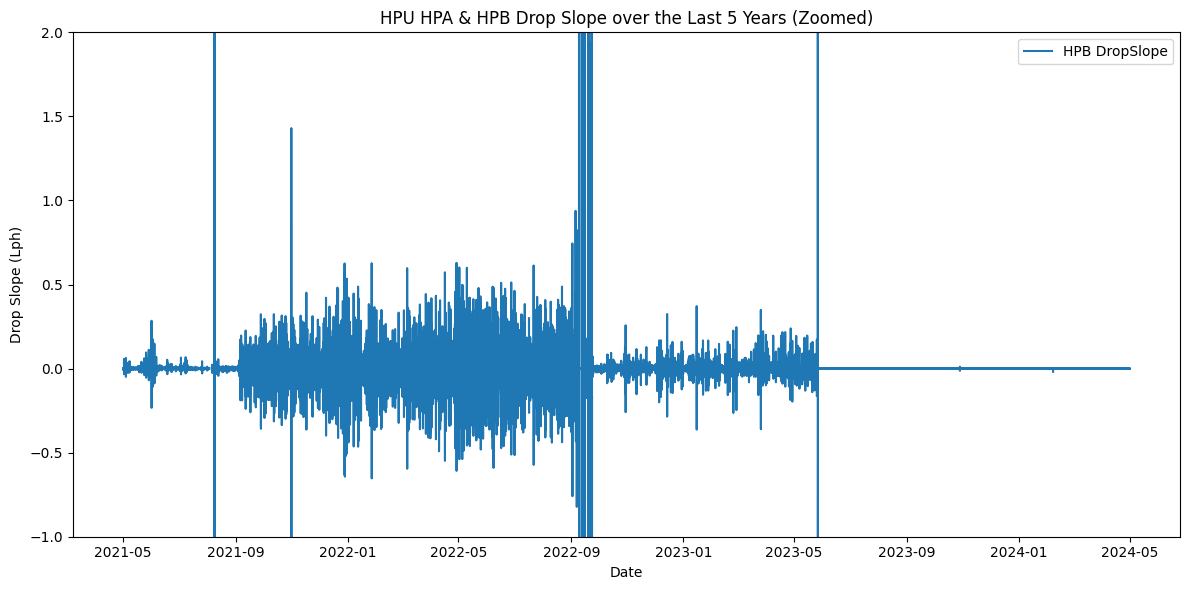

In [ ]:
# Look at the drop slopes calculated i.e. rate at which the fluid level is changeing 
# Plot HPA and HPB 2 hour lag

# Ensure datetime index
if not pd.api.types.is_datetime64_any_dtype(df_all_otter.index):
    df_all_otter.index = pd.to_datetime(df_all_otter['timestamp'])

# Last 5 years window
end_date   = df_all_otter.index.max()
start_date = end_date - pd.DateOffset(years=3)
df_5y = df_all_otter.loc[start_date:end_date, [
    "HPU_HPA_OUT_DropSlope_2h_Lph",
    "HPU_HPB_OUT_DropSlope_2h_Lph"
]]

# Plot with y-axis zoom
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_5y.index, df_5y["HPU_HPA_OUT_DropSlope_2h_Lph"], label="HPA DropSlope")
#ax.plot(df_5y.index, df_5y["HPU_HPB_OUT_DropSlope_8h_Lph"], label="HPB DropSlope")

ax.set_xlabel("Date")
ax.set_ylabel("Drop Slope (Lph)")
ax.set_title("HPU HPA & HPB Drop Slope over the Last 5 Years (Zoomed)")
ax.legend()
ax.set_ylim(-1, 2)    # <-- zoom y-axis between -1 and 2

plt.tight_layout()
plt.show()

# Plot with y-axis zoom
fig, ax = plt.subplots(figsize=(12, 6))
#ax.plot(df_5y.index, df_5y["HPU_HPA_OUT_DropSlope_8h_Lph"], label="HPA DropSlope")
ax.plot(df_5y.index, df_5y["HPU_HPB_OUT_DropSlope_2h_Lph"], label="HPB DropSlope")

ax.set_xlabel("Date")
ax.set_ylabel("Drop Slope (Lph)")
ax.set_title("HPU HPA & HPB Drop Slope over the Last 5 Years (Zoomed)")
ax.legend()
ax.set_ylim(-1, 2)    # <-- zoom y-axis between -1 and 2

plt.tight_layout()
plt.show()


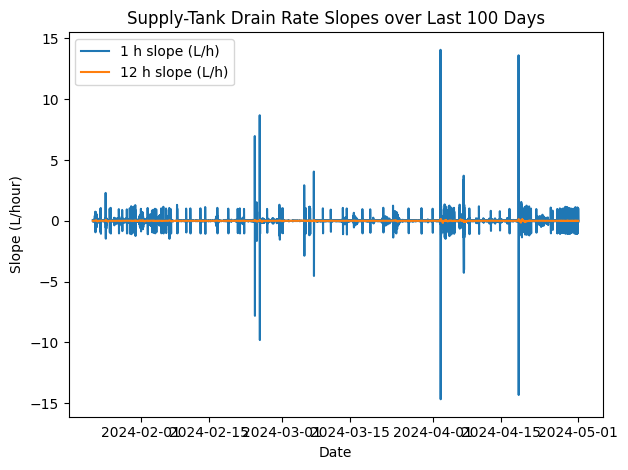

In [ ]:

# Plot last 100 days of Supply Tank 1 and 6 hour lags

df = df_all_otter.sort_index()

# 2) Define the 100-day window
end   = df.index.max()
start = end - pd.Timedelta(days=100)
df100 = df.loc[start:end]

# 3) Plot  four slopes 
plt.figure()

plt.plot(df100.index, df100['Slope_1H_Lph'],  label='1 h slope (L/h)')
plt.plot(df100.index, df100['Slope_12H_Lph'],  label='12 h slope (L/h)')

plt.title('Supply-Tank Drain Rate Slopes over Last 100 Days')
plt.xlabel('Date')
plt.ylabel('Slope (L/hour)')
plt.legend()
plt.tight_layout()
plt.show()

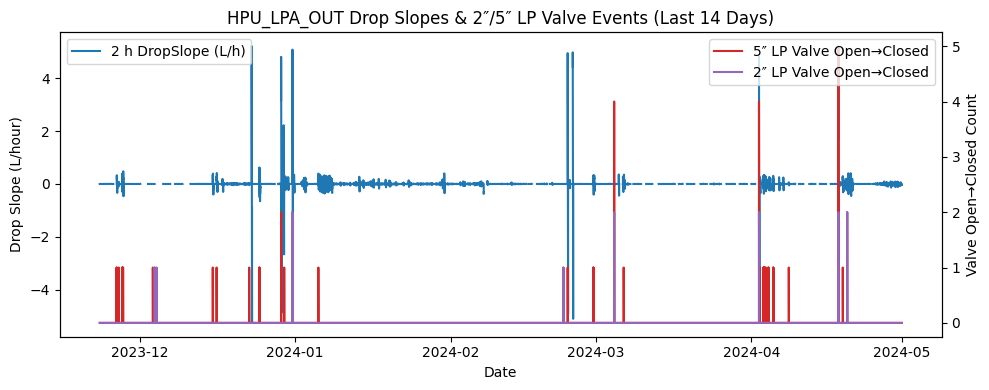

In [ ]:
# Plot LPA Drops Slopes with time lag and the LP Valve operations which hsould align

# 1) Prepare your 14-day slice
df = df_all_otter.sort_index()
end   = df.index.max()
start = end - pd.Timedelta(days=160)
df14  = df.loc[start:end]

# 2) Plot the 2h and 24h drop-slopes for HPU_LPA_OUT
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(df14.index, df14['HPU_LPA_OUT_DropSlope_2h_Lph'],  label='2 h DropSlope (L/h)')
#ax1.plot(df14.index, df14['HPU_LPA_OUT_DropSlope_8h_Lph'], label='24 h DropSlope (L/h)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Drop Slope (L/hour)')
ax1.legend(loc='upper left')

# 3) Overlay the 5″ and 2″ LP-valve counts on a twin axis
ax2 = ax1.twinx()
ax2.step(df14.index,
         df14['5_LP_Valve_OpenToClosed'],
         where='mid',
         color='tab:red',
         label='5″ LP Valve Open→Closed')
ax2.step(df14.index,
         df14['2_LP_Valve_OpenToClosed'],
         where='mid',
         color='tab:purple',
         label='2″ LP Valve Open→Closed')
ax2.set_ylabel('Valve Open→Closed Count')
ax2.legend(loc='upper right')

# 4) Final touches
plt.title('HPU_LPA_OUT Drop Slopes & 2″/5″ LP Valve Events (Last 14 Days)')
plt.tight_layout()
plt.show()

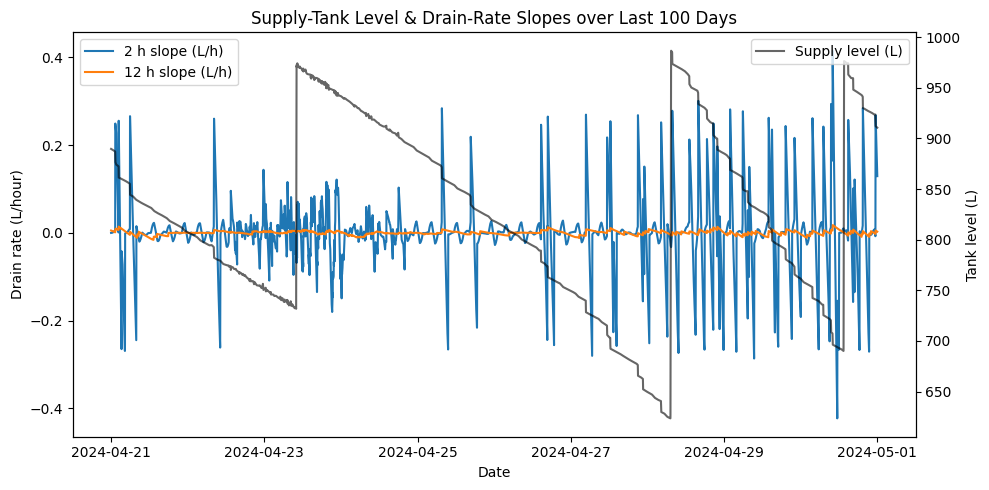

In [ ]:
# Plot over 100 days. Include Supply Tank Level and 2 hours and 12 hour time lags. 

# 1) Pick your time window; e.g. last 100 days
df = df_all_otter.sort_index()
end   = df.index.max()
start = end - pd.Timedelta(days=10)
dfw   = df.loc[start:end]

# 2) Start the figure and first axis (for slopes)
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(dfw.index, dfw['Slope_2H_Lph'],  label='2 h slope (L/h)')
ax1.plot(dfw.index, dfw['Slope_12H_Lph'], label='12 h slope (L/h)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Drain rate (L/hour)')
ax1.legend(loc='upper left')

# 3) Twin axis for tank level
ax2 = ax1.twinx()
ax2.plot(dfw.index, dfw['HPU_SPLY_LEV_L'], color='k', alpha=0.6, label='Supply level (L)')
ax2.set_ylabel('Tank level (L)')
ax2.legend(loc='upper right')

# 4) Polish
plt.title('Supply-Tank Level & Drain-Rate Slopes over Last 100 Days')
fig.tight_layout()
plt.show()


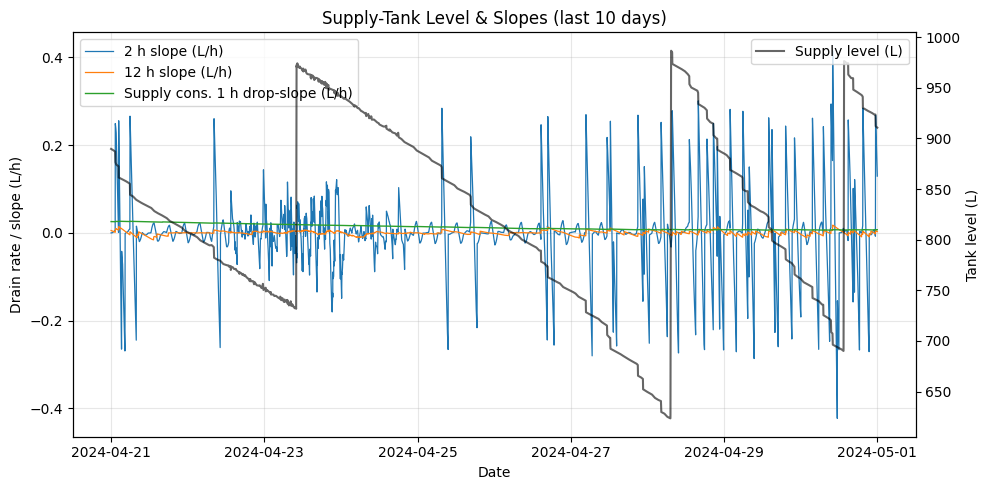

In [ ]:
# 1) Pick your time window (10 or 100 days)
df = df_all_otter.sort_index()
end   = df.index.max()
start = end - pd.Timedelta(days=10)  # change to 100 if you want
dfw   = df.loc[start:end]

# Optional: clip extreme slope outliers for visibility
clip = (-1.0, 1.0)  # L/h range for plotting
s2  = dfw['Slope_2H_Lph'].clip(*clip)
s12 = dfw['Slope_12H_Lph'].clip(*clip)

# New: supply-consumption drop slope (if present), clipped
if 'Supply_Consumption_Excl_Fills_DropSlope_1h_Lph' in dfw.columns:
    scons = dfw['Supply_Consumption_Excl_Fills_DropSlope_1h_Lph'].clip(*clip)
else:
    raise KeyError("Column 'Supply_Consumption_Excl_Fills_DropSlope_1h_Lph' not found.")

# 2) Plot slopes on left axis
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(dfw.index, s2,   label='2 h slope (L/h)', lw=0.9)
ax1.plot(dfw.index, s12,  label='12 h slope (L/h)', lw=0.9)
ax1.plot(dfw.index, scons,label='Supply cons. 1 h drop-slope (L/h)', lw=1.0)
ax1.set_xlabel('Date')
ax1.set_ylabel('Drain rate / slope (L/h)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 3) Tank level on right axis
ax2 = ax1.twinx()
ax2.plot(dfw.index, dfw['HPU_SPLY_LEV_L'], color='k', alpha=0.6, label='Supply level (L)')
ax2.set_ylabel('Tank level (L)')
ax2.legend(loc='upper right')

# 4) Title + layout
plt.title('Supply-Tank Level & Slopes (last 10 days)')
fig.tight_layout()
plt.show()


In [ ]:
list(df_all_otter.columns)


['HPU_SPLY_LEV',
 'HPU_RET_LEV',
 'HPU_LP_A_SPLY',
 'HPU_LP_B_SPLY',
 'HPU_HP_A_SPLY',
 'HPU_HP_B_SPLY',
 'HPU_LPA_OUT',
 'HPU_LPB_OUT',
 'HPU_HPA_OUT',
 'HPU_HPB_OUT',
 'SCM1_LP_CONS',
 'SCM1_HP_CONS',
 'SCM1_RET',
 'SCM2_LP_CONS',
 'SCM2_RET',
 'P3_PMV',
 'P3_PWV',
 'P3_AMV',
 'P3_SCSSV',
 'P3_PDV',
 'P3_TDV',
 'P1_PMV',
 'P1_PWV',
 'P1_AMV',
 'P1_SCSSV',
 'P1_PDV',
 'P1_TDV',
 'P2_PMV',
 'P2_PWV',
 'P2_AMV',
 'P2_SCSSV',
 'P2_PDV',
 'P2_TDV',
 'I1_PMV',
 'I1_PWV',
 'I1_AMV',
 'I2_PMV',
 'I2_PWV',
 'I2_AMV',
 'FCV_CPI',
 'P1_PCV',
 'P2_PCV',
 'P3_PCV',
 'I1_PCV',
 'I2_PCV',
 'MPMV_Inlet',
 'Man_CI',
 'SCM1_LP1_COV',
 'SCM1_HP_COV',
 'HPU_SPLY_LEV_B',
 'HPU-RET_LEV_B',
 'SCM2_LP1_COV',
 'SCM2_HP_COV',
 'SCM3_LP1_COV',
 'SCM3_HP_COV',
 'SCM4_LP1_COV',
 'SCM4_HP_COV',
 'SCM5_LP1_COV',
 'SCM5_HP_COV',
 'SCM3_LP_CONS',
 'SCM3_HP_CONS',
 'SCM3_RET',
 'SCM4_LP_CONS',
 'SCM4_HP_CONS',
 'SCM4_RET',
 'SCM5_LP_CONS',
 'SCM5_HP_CONS',
 'SCM5_RET',
 'P1_PMV_OpenToClosed',
 'P1_PMV_ClosedToOpen',


Explore and investigate the Returns data
**note the returns data didnt inform much so was disregarded going forward**

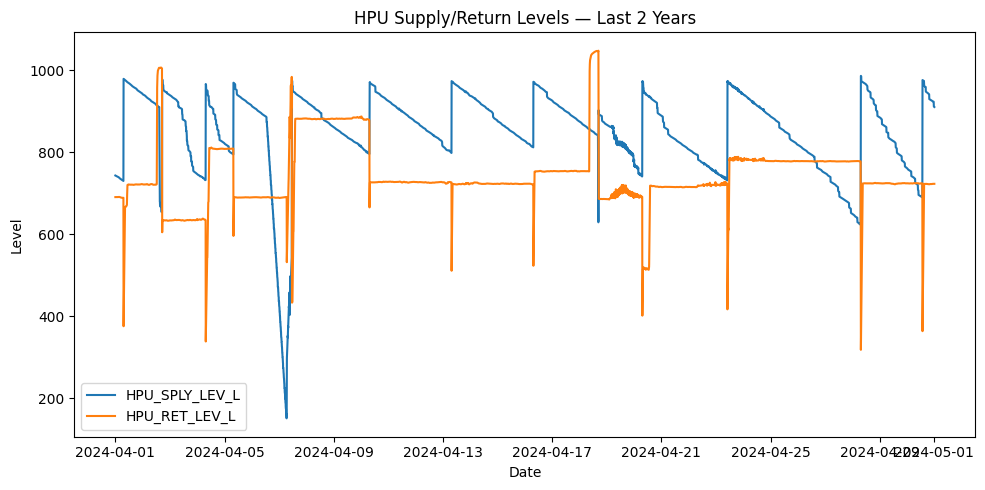

In [ ]:
# Return tank data work 
# --- CONFIG ---
ts_col_candidates = ["timestamp", "time", "date", "datetime"]  # rename/add if needed
cols_to_plot = ["HPU_SPLY_LEV_L", "HPU_RET_LEV_L"]

# --- MAKE SURE WE HAVE A DATETIME INDEX ---
df = df_all_otter.copy()

if not isinstance(df.index, pd.DatetimeIndex):
    # try to find a timestamp-like column
    ts_col = None
    for c in ts_col_candidates:
        if c in df.columns:
            ts_col = c
            break
    if ts_col is None:
        raise ValueError(
            f"Couldn't find a datetime index or any of {ts_col_candidates}. "
            "Set a datetime index or specify the timestamp column."
        )
    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce", utc=True)
    df = df.dropna(subset=[ts_col]).set_index(ts_col)

# ensure index is sorted and tz-naive for plotting
df = df.sort_index()
if df.index.tz is not None:
    df.index = df.index.tz_convert("UTC").tz_localize(None)

# --- FILTER LAST 2 YEARS FROM THE MAX DATE PRESENT ---
end = df.index.max()
start = end - pd.DateOffset(months=1)
df2 = df.loc[start:end, cols_to_plot].copy()

# optional: handle missing data sensibly
df2 = df2.astype("float64")
df2 = df2.interpolate(limit_direction="both")

# --- PLOT ---
plt.figure(figsize=(10, 5))
for c in cols_to_plot:
    if c not in df2.columns:
        raise KeyError(f"Column '{c}' not found in df_all_otter.")
    plt.plot(df2.index, df2[c], label=c)

plt.title("HPU Supply/Return Levels — Last 2 Years")
plt.xlabel("Date")
plt.ylabel("Level")
plt.legend()
plt.tight_layout()
plt.show()



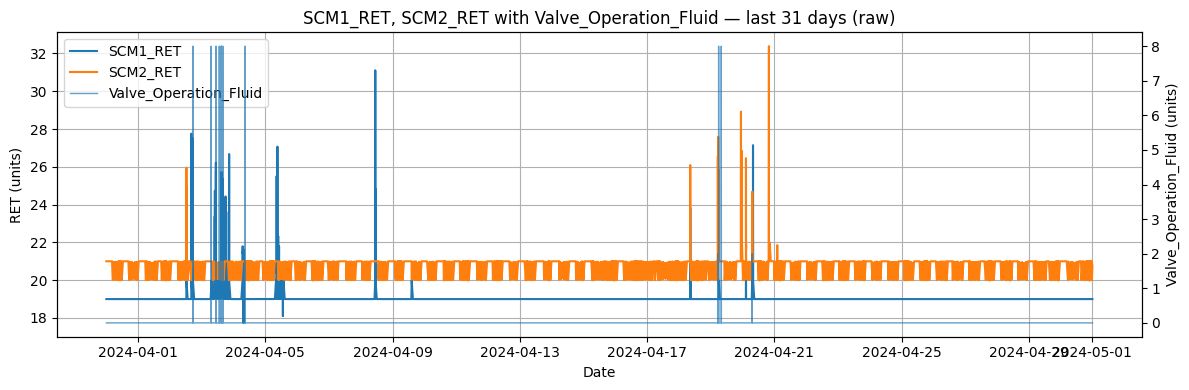

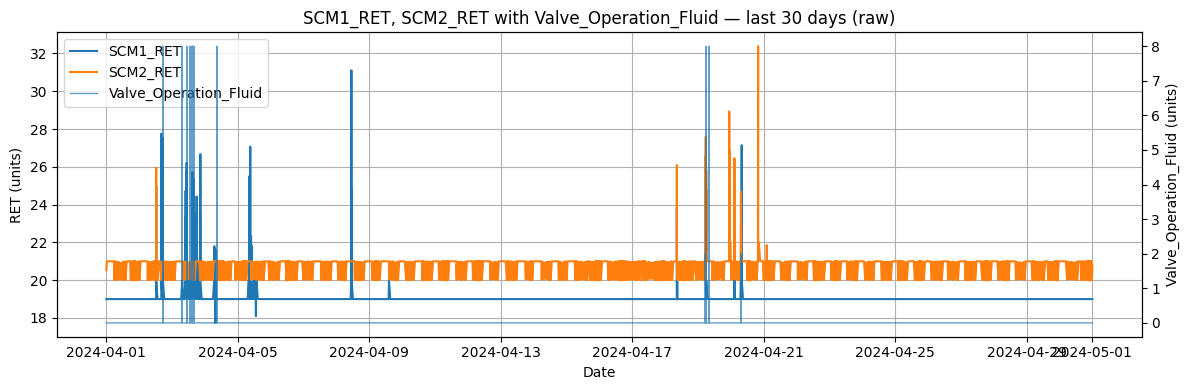

In [ ]:


def plot_rets_with_valve_last_month(
    df,
    ret_cols=("SCM1_RET", "SCM2_RET"),
    valve_col="Valve_Operation_Fluid",
    days=31
):
    # Minimal hygiene
    d = df.copy()
    d.index = pd.to_datetime(d.index)
    d = d[~d.index.duplicated(keep="first")].sort_index()

    # Keep only existing columns
    ret_cols_ok = [c for c in ret_cols if c in d.columns]
    if not ret_cols_ok:
        raise KeyError(f"None of {ret_cols} found in DataFrame columns.")
    if valve_col not in d.columns:
        raise KeyError(f"Column '{valve_col}' not found in DataFrame.")

    # Slice last N days
    dm = d.last(f"{days}D")
    dm = dm[ret_cols_ok + [valve_col]].astype(float)

    fig, ax = plt.subplots(figsize=(12, 4))

    # Left axis: returns
    for c in ret_cols_ok:
        ax.plot(dm.index, dm[c], label=c)
    ax.set_xlabel("Date")
    ax.set_ylabel("RET (units)")
    ax.grid(True)

    # Right axis: valve usage (often much smaller or spiky)
    ax2 = ax.twinx()
    ax2.plot(dm.index, dm[valve_col], linewidth=1, alpha=0.7, label=valve_col)
    ax2.set_ylabel("Valve_Operation_Fluid (units)")

    # Build a combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.title(f"{', '.join(ret_cols_ok)} with {valve_col} — last {days} days (raw)")
    plt.tight_layout()
    plt.show()

# Usage:
plot_rets_with_valve_last_month(df_all_otter)           # 31 days
plot_rets_with_valve_last_month(df_all_otter, days=30)  # 30 days


Explore LP and HP Pressure deltas between the subsea and topside instruments 

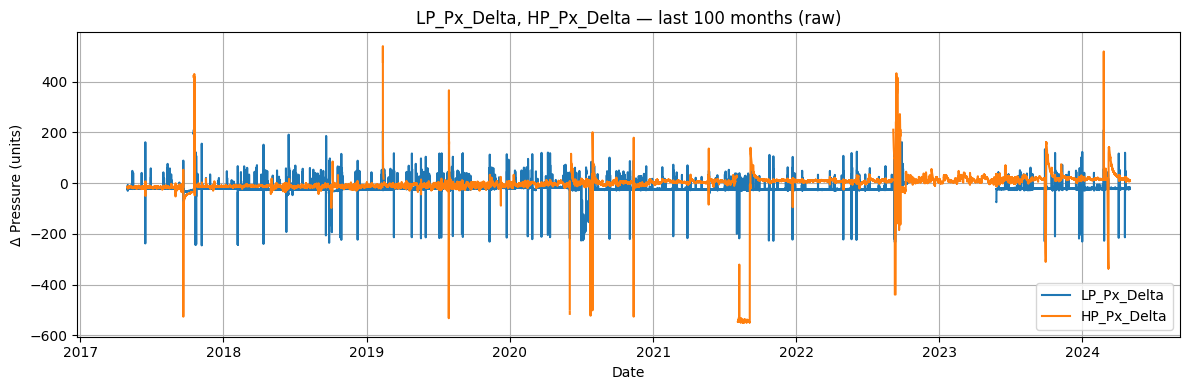

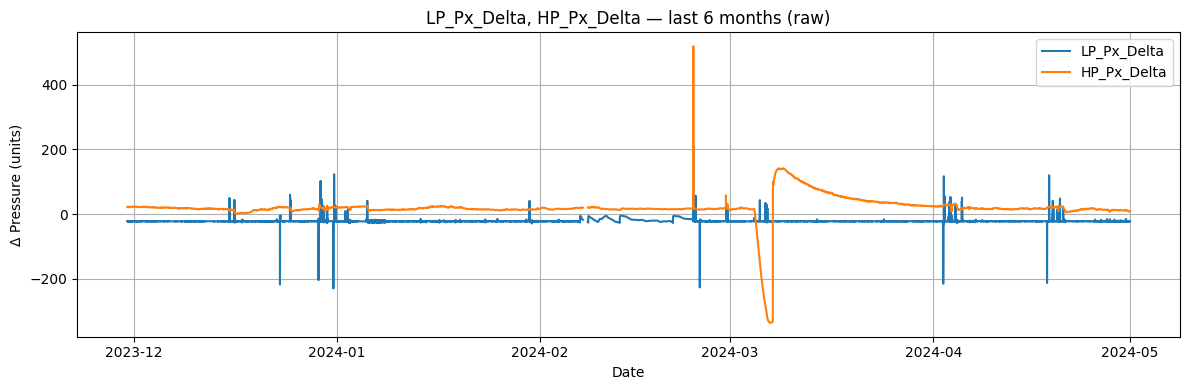

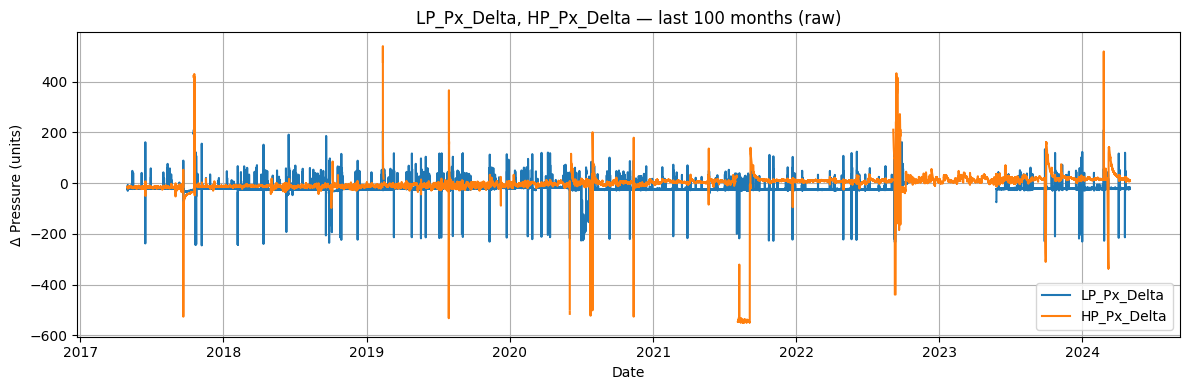

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_px_deltas_4m(df, cols=("LP_Px_Delta", "HP_Px_Delta"), months=100):
    # Minimal hygiene
    d = df.copy()
    d.index = pd.to_datetime(d.index)
    d = d[~d.index.duplicated(keep="first")].sort_index()

    # Keep only columns that exist
    cols_ok = [c for c in cols if c in d.columns]
    if not cols_ok:
        raise KeyError(f"None of {cols} found in DataFrame columns.")

    # Slice last N months (~120 days)
    dm = d.last(f"{months}M")[cols_ok].astype(float)

    plt.figure(figsize=(12, 4))
    for c in cols_ok:
        plt.plot(dm.index, dm[c], label=c)

    plt.title(f"{', '.join(cols_ok)} — last {months} months (raw)")
    plt.xlabel("Date")
    plt.ylabel("Δ Pressure (units)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Usage:
plot_px_deltas_4m(df_all_otter)                  # default 4 months
plot_px_deltas_4m(df_all_otter, months=6)        # e.g., 6 months
plot_px_deltas_4m(df_all_otter, cols=["LP_Px_Delta","HP_Px_Delta"])


Explore the umbilicial charge data. Charge events were identified in pipeline

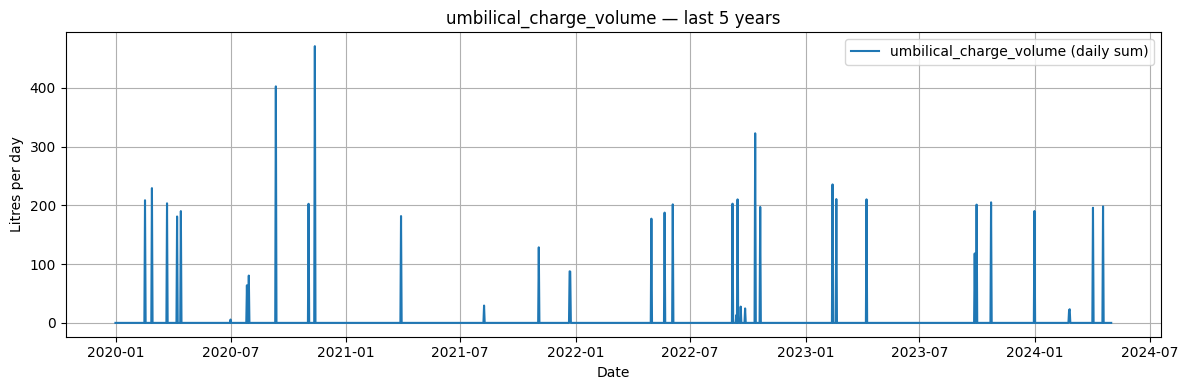

In [ ]:

def plot_umb_charge_5y(df, col="umbilical_charge_volume", years=5):
    # Minimal hygiene
    d = df.copy()
    d.index = pd.to_datetime(d.index)
    d = d[~d.index.duplicated(keep="first")].sort_index()

    if col not in d.columns:
        raise KeyError(f"Column '{col}' not found.")

    # Keep last N years
    dN = d.last(f"{years}Y")

    # Aggregate to daily for legibility over multi-year span
    daily = dN[col].astype(float).resample("D").sum()   # or .mean() if preferred

    plt.figure(figsize=(12, 4))
    plt.plot(daily.index, daily.values, label=f"{col} (daily sum)")
    plt.title(f"{col} — last {years} years")
    plt.xlabel("Date")
    plt.ylabel("Litres per day")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Usage:
plot_umb_charge_5y(df_all_otter)  # default 5 years


In [ ]:
df_all_otter=clean_dataframe(df_all_otter)

In [ ]:
df_all_otter.to_parquet("df_all_otter_clean_post_pipeline_v4_240825.parquet", index=True)

In [ ]:
list(df_all_otter.columns)

['HPU_SPLY_LEV',
 'HPU_RET_LEV',
 'HPU_LP_A_SPLY',
 'HPU_LP_B_SPLY',
 'HPU_HP_A_SPLY',
 'HPU_HP_B_SPLY',
 'HPU_LPA_OUT',
 'HPU_LPB_OUT',
 'HPU_HPA_OUT',
 'HPU_HPB_OUT',
 'SCM1_LP_CONS',
 'SCM1_HP_CONS',
 'SCM1_RET',
 'SCM2_LP_CONS',
 'SCM2_RET',
 'P3_PMV',
 'P3_PWV',
 'P3_AMV',
 'P3_SCSSV',
 'P3_PDV',
 'P3_TDV',
 'P1_PMV',
 'P1_PWV',
 'P1_AMV',
 'P1_SCSSV',
 'P1_PDV',
 'P1_TDV',
 'P2_PMV',
 'P2_PWV',
 'P2_AMV',
 'P2_SCSSV',
 'P2_PDV',
 'P2_TDV',
 'I1_PMV',
 'I1_PWV',
 'I1_AMV',
 'I2_PMV',
 'I2_PWV',
 'I2_AMV',
 'FCV_CPI',
 'P1_PCV',
 'P2_PCV',
 'P3_PCV',
 'I1_PCV',
 'I2_PCV',
 'MPMV_Inlet',
 'Man_CI',
 'SCM1_LP1_COV',
 'SCM1_HP_COV',
 'HPU_SPLY_LEV_B',
 'HPU-RET_LEV_B',
 'SCM2_LP1_COV',
 'SCM2_HP_COV',
 'SCM3_LP1_COV',
 'SCM3_HP_COV',
 'SCM4_LP1_COV',
 'SCM4_HP_COV',
 'SCM5_LP1_COV',
 'SCM5_HP_COV',
 'SCM3_LP_CONS',
 'SCM3_HP_CONS',
 'SCM3_RET',
 'SCM4_LP_CONS',
 'SCM4_HP_CONS',
 'SCM4_RET',
 'SCM5_LP_CONS',
 'SCM5_HP_CONS',
 'SCM5_RET',
 'P1_PMV_OpenToClosed',
 'P1_PMV_ClosedToOpen',


In [ ]:
def summarise_dataframe(df):
    summary = []

    for col in df.columns:
        dtype = df[col].dtype
        n_missing = df[col].isna().sum()
        n_unique = df[col].nunique(dropna=True)
        examples = df[col].dropna().unique()[:5]  # up to 5 sample values

        col_summary = {
            'Column': col,
            'DType': dtype,
            'Missing': n_missing,
            'Unique': n_unique,
            'Examples': examples
        }

        if pd.api.types.is_numeric_dtype(df[col]):
            col_summary['Mean'] = df[col].mean()
            col_summary['Std'] = df[col].std()
            col_summary['Min'] = df[col].min()
            col_summary['Max'] = df[col].max()
        else:
            col_summary['Mean'] = None
            col_summary['Std'] = None
            col_summary['Min'] = None
            col_summary['Max'] = None

        summary.append(col_summary)

    summary_df = pd.DataFrame(summary)
    return summary_df

In [ ]:
summary_df = summarise_dataframe(df_all_otter)


In [ ]:
print(summary_df.head(55))  # Display first 20 rows (optional)

                     Column    DType  Missing   Unique  \
0            HPU_SPLY_LEV_L  float64   148425  6754755   
1             HPU_RET_LEV_L  float64  3793152  5137670   
2             HPU_LP_A_SPLY  float64   148010  1727814   
3             HPU_LP_B_SPLY  float64   147977  1704799   
4             HPU_HP_A_SPLY  float64   147982  1594517   
5             HPU_HP_B_SPLY  float64   147985  1568382   
6               HPU_LPA_OUT  float64   472497  2797304   
7               HPU_LPB_OUT  float64   148107  2522582   
8               HPU_HPA_OUT  float64   149367  1890061   
9               HPU_HPB_OUT  float64   147974  7788523   
10             SCM1_LP_CONS  float64   199757  2145985   
11             SCM1_HP_CONS  float64  1491327  1009270   
12                 SCM1_RET  float64   199867   526870   
13             SCM2_LP_CONS  float64   264379  2160650   
14                 SCM2_RET  float64   264379   981491   
15                   P3_PMV    int32        0        3   
16            

In [ ]:
list(df_all_otter.columns)

['HPU_SPLY_LEV',
 'HPU_RET_LEV',
 'HPU_LP_A_SPLY',
 'HPU_LP_B_SPLY',
 'HPU_HP_A_SPLY',
 'HPU_HP_B_SPLY',
 'HPU_LPA_OUT',
 'HPU_LPB_OUT',
 'HPU_HPA_OUT',
 'HPU_HPB_OUT',
 'SCM1_LP_CONS',
 'SCM1_HP_CONS',
 'SCM1_RET',
 'SCM2_LP_CONS',
 'SCM2_RET',
 'P3_PMV',
 'P3_PWV',
 'P3_AMV',
 'P3_SCSSV',
 'P3_PDV',
 'P3_TDV',
 'P1_PMV',
 'P1_PWV',
 'P1_AMV',
 'P1_SCSSV',
 'P1_PDV',
 'P1_TDV',
 'P2_PMV',
 'P2_PWV',
 'P2_AMV',
 'P2_SCSSV',
 'P2_PDV',
 'P2_TDV',
 'I1_PMV',
 'I1_PWV',
 'I1_AMV',
 'I2_PMV',
 'I2_PWV',
 'I2_AMV',
 'FCV_CPI',
 'P1_PCV',
 'P2_PCV',
 'P3_PCV',
 'I1_PCV',
 'I2_PCV',
 'MPMV_Inlet',
 'Man_CI',
 'SCM1_LP1_COV',
 'SCM1_HP_COV',
 'HPU_SPLY_LEV_B',
 'HPU-RET_LEV_B',
 'SCM2_LP1_COV',
 'SCM2_HP_COV',
 'SCM3_LP1_COV',
 'SCM3_HP_COV',
 'SCM4_LP1_COV',
 'SCM4_HP_COV',
 'SCM5_LP1_COV',
 'SCM5_HP_COV',
 'SCM3_LP_CONS',
 'SCM3_HP_CONS',
 'SCM3_RET',
 'SCM4_LP_CONS',
 'SCM4_HP_CONS',
 'SCM4_RET',
 'SCM5_LP_CONS',
 'SCM5_HP_CONS',
 'SCM5_RET',
 'P1_PMV_OpenToClosed',
 'P1_PMV_ClosedToOpen',


In [ ]:
# function ro calcaute additoanl drop slopes if required
from joblib import Parallel, delayed
def calculate_drop_slopes(df, cols, windows=None, to_per='h', n_jobs=-1):
    """
    Calculate rolling drop-only slopes for given columns over specified time windows, in parallel.

    Parameters:
    - df: pandas DataFrame with a datetime index.
    - cols: list of column names to process.
    - windows: dict of label -> window string, e.g., {'1h': '1H'}
    - to_per: 'h' for L/h output, 's' for L/s output.
    - n_jobs: number of parallel workers (default = all cores)

    Returns:
    - Modified DataFrame with new slope columns added.
    """
    df = df.copy()
    df = df.sort_index()

    if windows is None:
        windows = {
            '1h': '1H',
            '8h': '8H'
        }

    def _slope_seconds_safe(x):
        t = x.index.astype(np.int64) // 10**9
        y = x.values
        mask = ~np.isnan(y)
        if mask.sum() < 2 or np.nanstd(y[mask]) == 0:
            return np.nan
        try:
            return np.polyfit(t[mask], y[mask], 1)[0]
        except np.linalg.LinAlgError:
            return np.nan

    def compute_single_feature(col, label, win, to_per):
        print(f"--> Starting: {col} [{label}]")
        drop_only = df[col].diff().clip(upper=0).abs
        
        ()
        slopes = drop_only.rolling(win, min_periods=2).apply(_slope_seconds_safe, raw=False)
        slopes = slopes * (3600 if to_per == 'h' else 1)
        new_col = f"{col}_DropSlope_{label}_Lph" if to_per == 'h' else f"{col}_DropSlope_{label}_Lps"
        print(f"✓ Completed: {new_col}")
        return new_col, slopes

    # Run in parallel
    tasks = [(col, label, win, to_per) for col in cols for label, win in windows.items()]
    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_single_feature)(col, label, win, to_per) for col, label, win, to_per in tasks
    )

    # Assign results back to DataFrame
    for new_col, series in results:
        df[new_col] = series

    print("All slope features computed (parallel).")
    return df

In [ ]:
#subsea_slopes = ['SCM1_LP_CONS', 'SCM1_HP_CONS']
#df_all_otter = calculate_drop_slopes(df_all_otter, subsea_slopes, n_jobs=-1)

In [ ]:
# Define output file path
#SCM_drop_slope_data_path = r"C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\data\Slope_Features_Only_SCM.parquet"

# Identify the newly added slope columns
#slope_cols = [col for col in df_all_otter.columns if any(base in col for base in subsea_slopes) and 'DropSlope' in col]

# Create a DataFrame with only the slope features
#df_slope_only = df_all_otter[slope_cols]

# Save to Parquet
#df_slope_only.to_parquet(SCM_drop_slope_data_path)

#print(f"Slope features saved to {SCM_drop_slope_data_path}")

In [ ]:
# Save the PArquet File


out_path = Path(r"C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\data\df_all_otter_clean_post_pipeline_2308_v3.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)

df_all_otter.to_parquet(out_path, engine="pyarrow", compression="zstd", index=True)
print("Saved to:", out_path)

Saved to: C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\data\df_all_otter_clean_post_pipeline_2308_v3.parquet
